# Fractional Brownian Motion Using Variance Ratio Tests

Consider a sample of $t$ measurements,

$
\begin{align}
X_0, X_1, X_2, \ldots, X_t
\end{align}
\tag{1}
$

A test is desired to determine if the series represents brownian motion, which is defined by,

$
\begin{align}
X_t = \sum_{i=1}^t X_i - X_{i-1} = \sum_{i=1}^t \Delta X_{i}
\end{align}
\tag{2}
$

where $\Delta X_i$ are independent and identically distributed with distribution,

$
\begin{align}
\Delta X_i \sim \text{Normal}(0, \sigma^2)
\end{align}
\tag{3}
$

and

$
\begin{align}
\text{Cov}(\Delta X_i \Delta X_j) = \sigma^2 \delta_{ij}
\end{align}
\tag{4}
$

This is the homoscedasticity assumption. Consider the difference,

$
\begin{align}
\Delta X_i(s) = X_i - X_{i+s}
\end{align}
\tag{5}
$

So that,

$
\begin{align}
X_t = \sum_{i=1}^n \Delta X_i(s)
\end{align}
\tag{6}
$

with $t=ns$. Let, 

$
\begin{align}
\sigma^2(s) = \text{Var}\left(\Delta X_i (s) \right)
\end{align}
\tag{7}
$

Recall for brownian motion $\sigma_B^2(t) = \sigma^2t$, it follows that $\sigma^2_B(s) = \sigma^2(1)s$. Consider the ratio,

$
\begin{align}
\text{VR}(s) = \frac{\sigma^2(s)}{\sigma_B^2(s)}
\end{align}
\tag{8}
$

where,

$
\begin{align}
&\sigma^2(1) = \frac{1}{t-1} \sum_{i=1}^t \left(X_i - X_{i-1} - \mu \right) \\
&\mu = \frac{1}{t} \left( X_t - X_0 \right)
\end{align}
\tag{9}
$

In Lo and Mackinlay, 1988, "Stock market Prices do not Follow Random Walks" it was shown that an unbiased estimator of $\sigma^2(s)$ is given by,

$
\begin{align}
\sigma^2(s) = \frac{1}{m} \sum_{i=s}^t \left( X_t - X_{t-s} - s\mu \right)^2
\end{align}
\tag{10}
$

where,

$
\begin{align}
m = \left(t - s + 1 \right) \left( 1 - \frac{s}{t} \right)
\end{align}
\tag{11}
$

If $X_t$ is brownian motion, $\sigma^2(s) = \sigma^2(1)$, $s = \sigma^2_B(s)$. It follows that $\text{VR}(s) = 1$. A test statistic for this condition is given by,

$
\begin{align}
Z(s) = \frac{\text{VR}(s) - 1}{\sqrt{\theta(s)}}
\end{align}
\tag{12}
$

where,

$
\begin{align}
\theta(s) = \frac{2\left( 2s - 1 \right)\left( s - 1 \right)}{3st}
\end{align}
\tag{13}
$

and $Z(s) \sim \text{Normal}(0,1)$. This test-statistic was derived assuming homoscedasticity which implies that the random component is independent of $s$. If instead the random component varies with $s$ heteroscedasticity is assumed.

For this case the test-statistic is given by,

$
\begin{align}
Z^\ast(s) = \frac{\text{VR}(s) - 1}{\sqrt{\theta^\ast (s)}}
\end{align}
\tag{14}
$

where,

$
\begin{align}
&\theta^\ast (s) = \sum_{j=1}^{s-1} \left[ \frac{2\left( s - j \right) } {s} \right]^2 \hat{\delta}(j) \\
&\hat{\delta}(j) = \frac{\sum_{i=j+1}^t \left( X_i - X_{i-1} - \mu \right)^2 \left( X_{i-j} - X_{i-j-1} - \mu \right)^2}{\left[ \sum_{i=1}^t \left( X_i - X_{i-1} - \mu \right)^2 \right]^2}
\end{align}
\tag{15}
$

The significance test using $Z(s)$ and $Z^\ast(s)$ succeeds if the time series is brownian motion. This test is implemented using two tails and the series is brownian motion if it succeeds. A test for $H<0.5$ uses a lower tail test and succeeds if the test for brownian motion fails. Similarly, A test for $H>0.5$ would use an upper tail test and succeed if the test for brownian motion fails.

## Import

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import fbm, stats, HypothesisTestType
from lib.plots import fpoints, comparison, curve, variance_ratio_test, PlotType
from lib.utils import create_parameter_scan, apply_to_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
def create(H_vals, npts):
    params = [{"H": H, "npts": npts} for H in H_vals]
    source = lambda **kwargs: fbm.create_fft_source(**kwargs)
    return create_parameter_scan(source, *params)

def lag_var_plot(samples, H, npts):
    title = f"Simulated FBM Lagged Variance: H={H}"
    labels = [r"$\sigma^2(s)$", r"$s^{2H}$"]
    s_vals, lag_var = stats.compute_lag_var(samples, smax=npts/10, npts=100)
    t, fbm_var = fbm.compute_var(numpy.array(s_vals)[::5], H=H)
    fpoints(data=lag_var, func=fbm_var, x=s_vals, fx=t, plot_axis_type=PlotType.LOG, title=title, labels=labels, xlabel=r"$s$", ylabel=r"$\sigma^2(s)$")

def vr_plot(samples, H, npts):
    title = f"Simulated FBM Variance Ratio: H={H}"
    labels = [r"VR$(s)$", r"$s^{2H-1}$"]
    s_vals, vr = fbm.compute_vr_scan(samples, smax=npts/10, npts=100)
    t, fbm_vr = fbm.compute_vr(numpy.array(s_vals)[::5], H=H)
    fpoints(data=vr, func=fbm_vr, x=s_vals, fx=t, title=title, labels=labels, plot_axis_type=PlotType.LOG, xlabel=r"$s$", ylabel=r"VR$(s)$")
    
def homo_test_stat_plot(report, H):
    title = f"Homoscedastic Variance Ratio Test: H={H}"
    variance_ratio_test(report, title=title)

def hetero_test_stat_plot(report, H):
    title = f"Heteroscedastic Variance Ratio Test: H={H}"
    variance_ratio_test(report, title=title)
    
def H_labels(H_vals):
    return [f"H={format(H, '1.2f')}" for H in H_vals]

## $\sigma^2 (s)$ and $\text{VR}(s)$ Verification

The $\sigma^2 (s)$ calculation is verified by comparing with $s^{2H}$. The variance ratio is given by,

$
\begin{align}
\text{VR}(s) = \frac{\sigma^2(s)}{\sigma_B^2(s)}
\end{align}
$

Since $\sigma^2(s) \sim s^{2H}$ and $\sigma_B^2(s) \sim s$ it follows that $\text{VR}(s) \sim s^{2H - 1}$.

In [3]:
npts = 2**16
H_vals = [0.5, 0.3, 0.8]
t, samples = create(H_vals, npts)

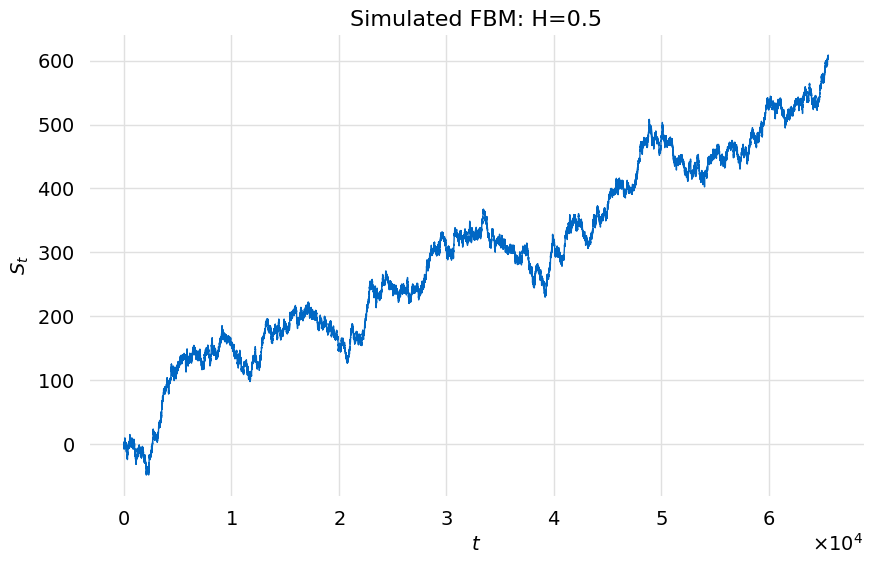

In [4]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

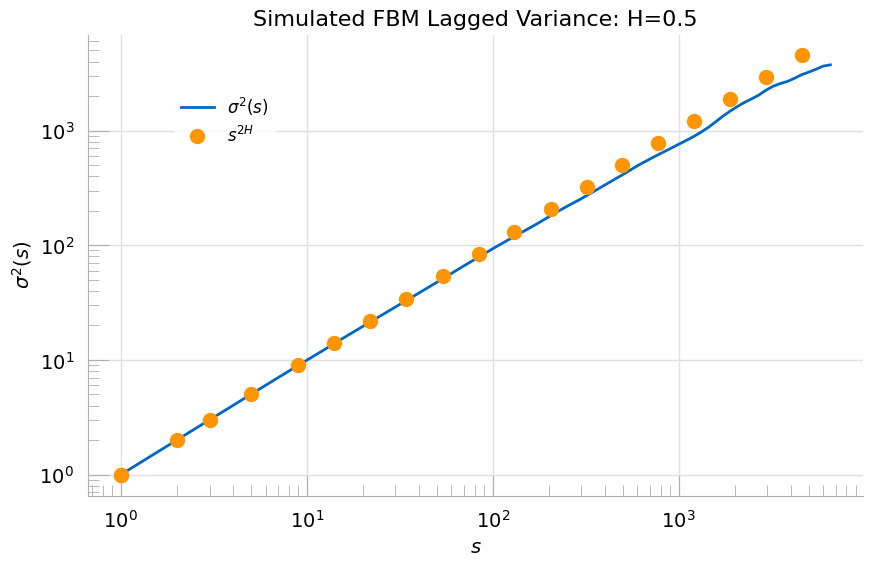

In [5]:
lag_var_plot(samples[0], H_vals[0], npts)

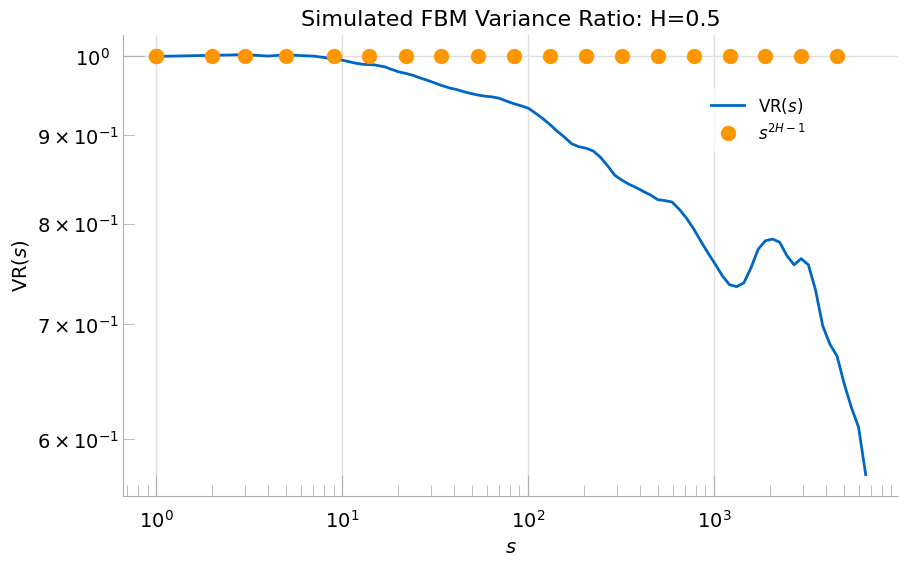

In [6]:
vr_plot(samples[0], H_vals[0], npts)

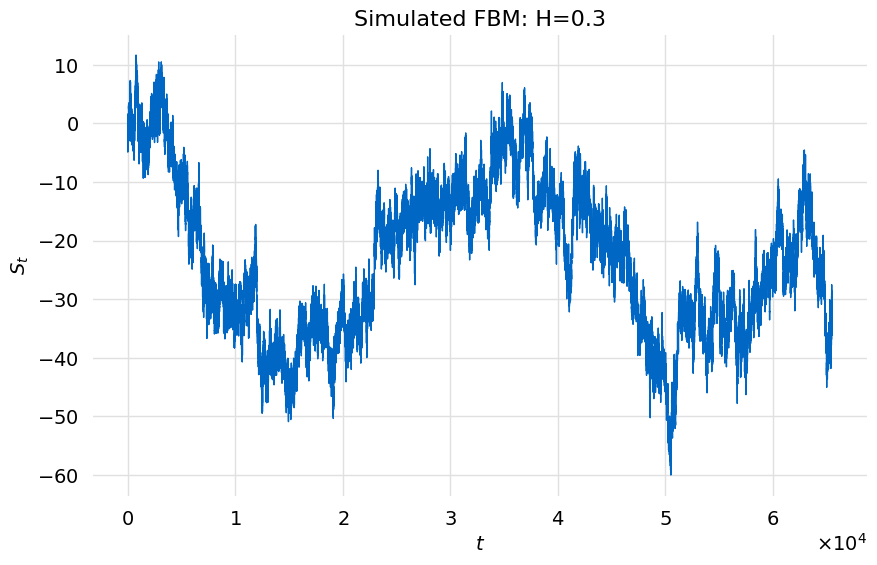

In [7]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

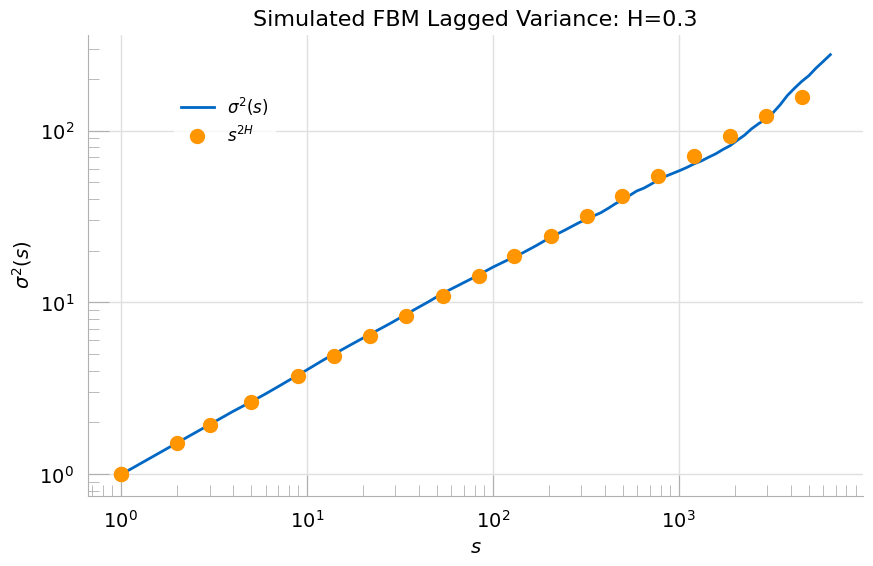

In [8]:
lag_var_plot(samples[1], H_vals[1], npts)

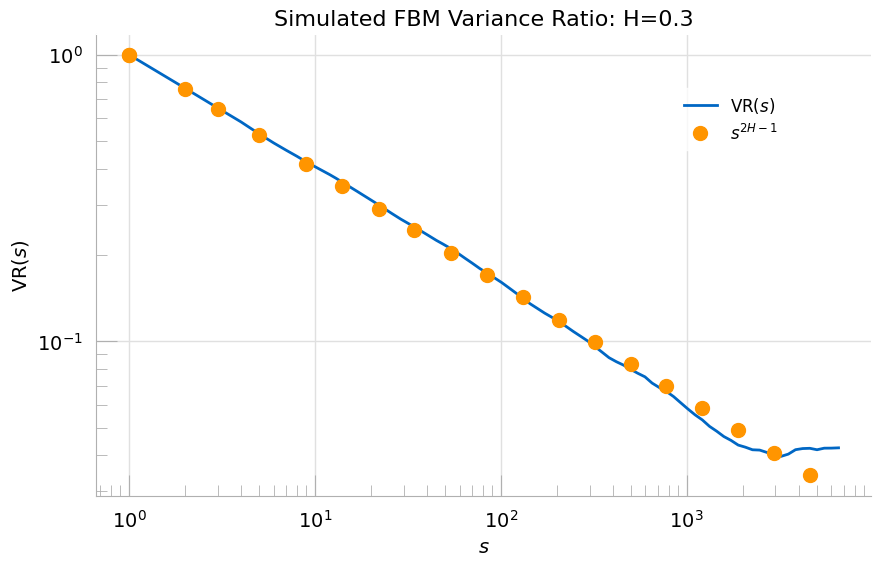

In [9]:
vr_plot(samples[1], H_vals[1], npts)

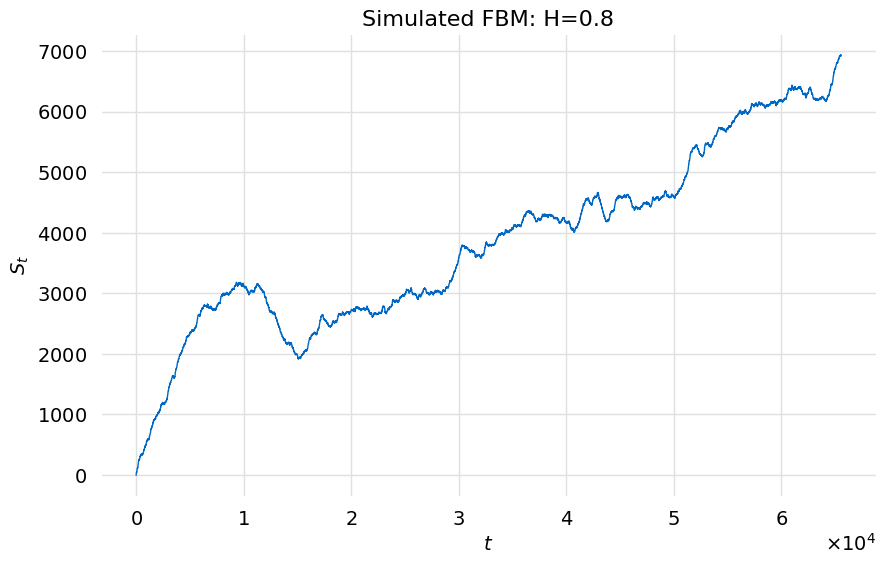

In [10]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

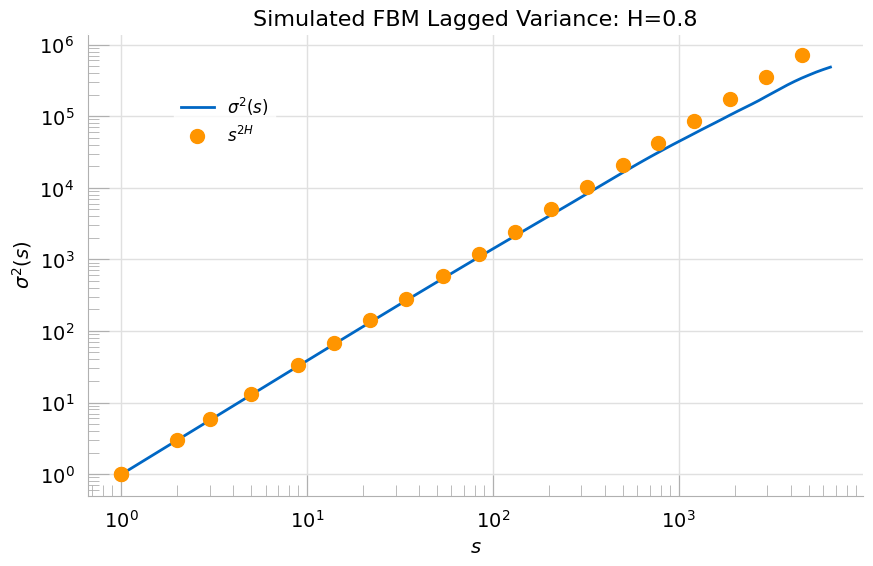

In [11]:
lag_var_plot(samples[2], H_vals[2], npts)

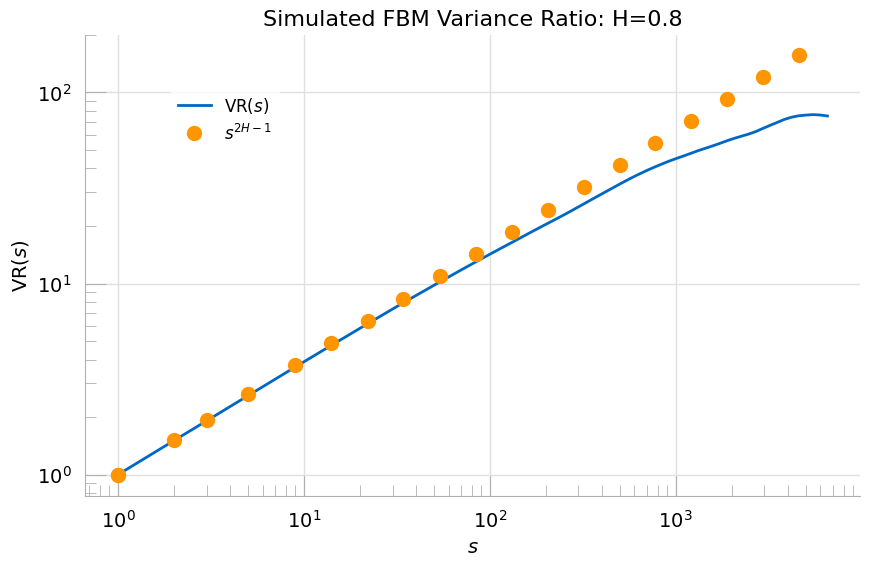

In [12]:
vr_plot(samples[2], H_vals[2], npts)

## Small Sample Size

In the previous verification section a rather large sample size was used to provide enough data to compute accurate averages. In general</br>
this is not practical. here more realistic sample sizes are used to see the impact on the analysis. 

In [13]:
npts = 2**9
H_vals = [0.5, 0.3, 0.8]
t, samples = create(H_vals, npts)

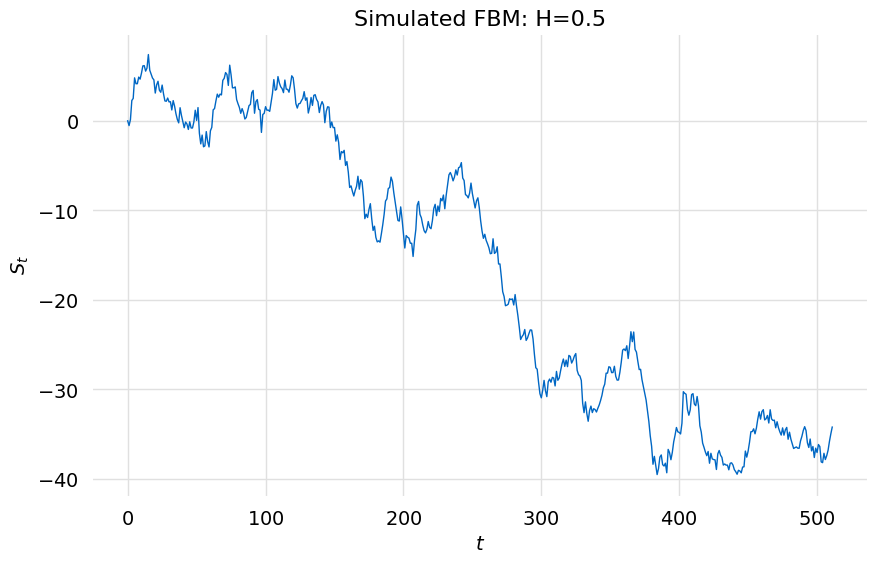

In [14]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

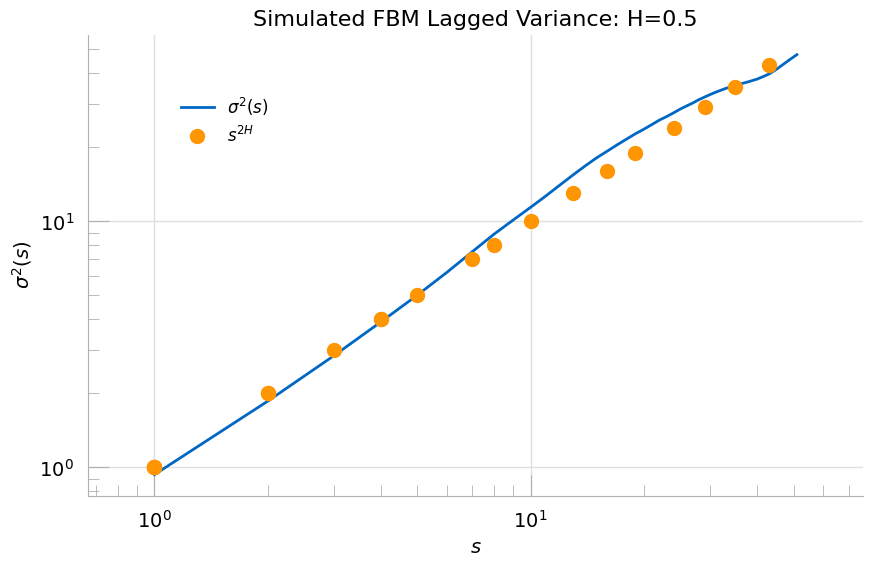

In [15]:
lag_var_plot(samples[0], H_vals[0], npts)

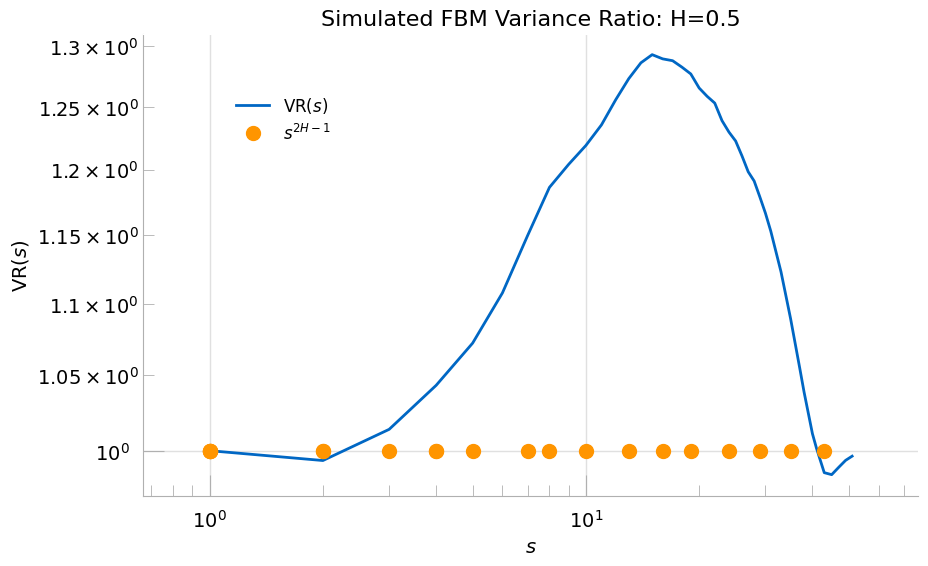

In [16]:
vr_plot(samples[0], H_vals[0], npts)

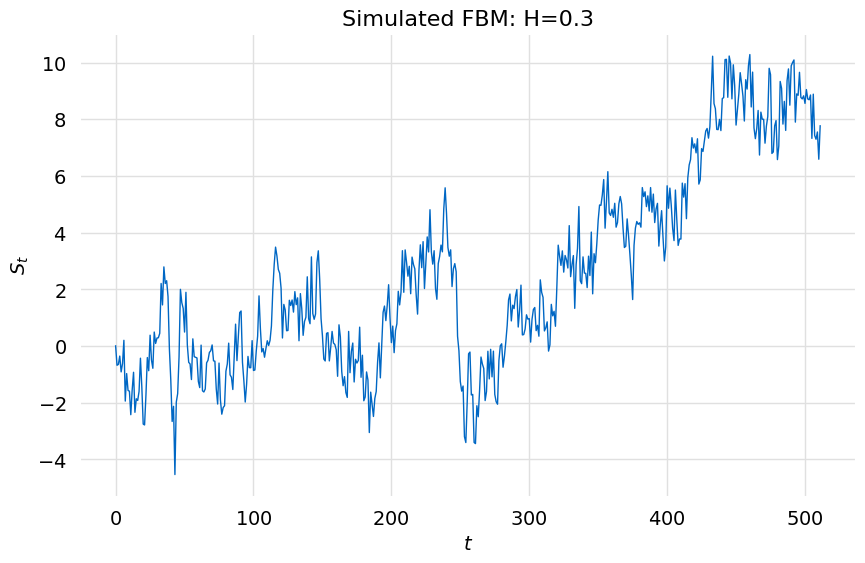

In [17]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

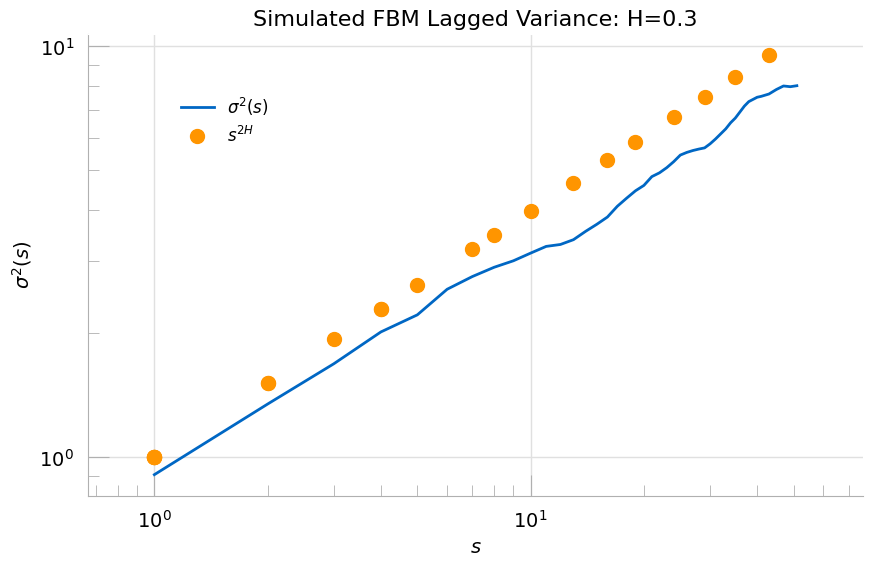

In [18]:
lag_var_plot(samples[1], H_vals[1], npts)

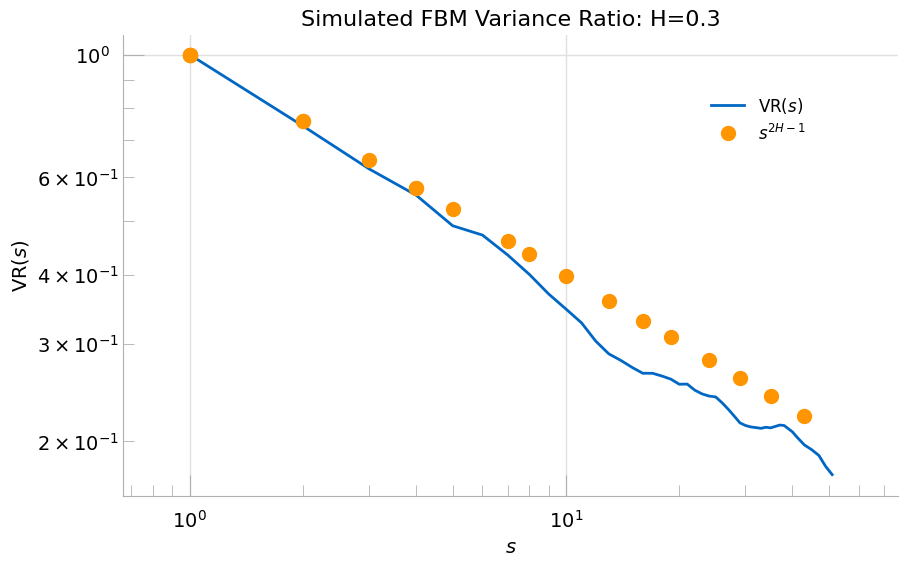

In [19]:
vr_plot(samples[1], H_vals[1], npts)

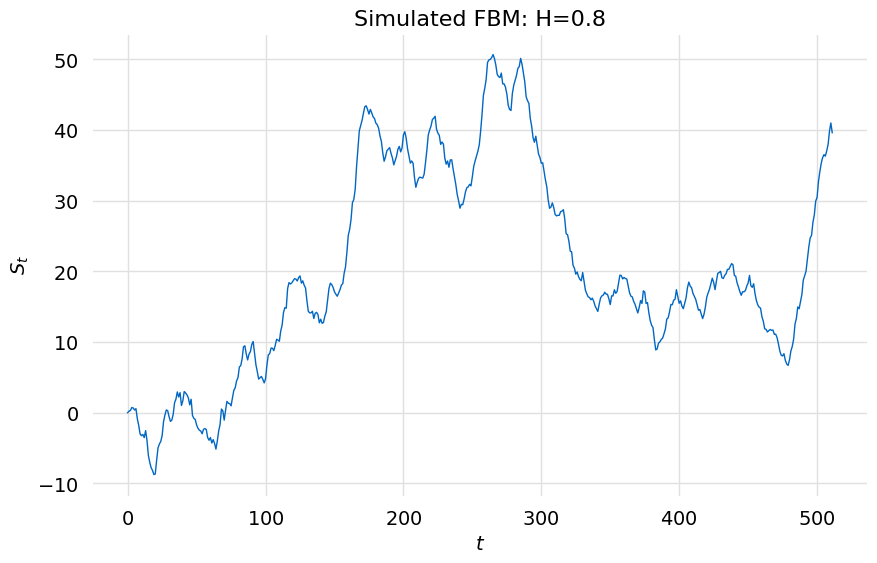

In [20]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

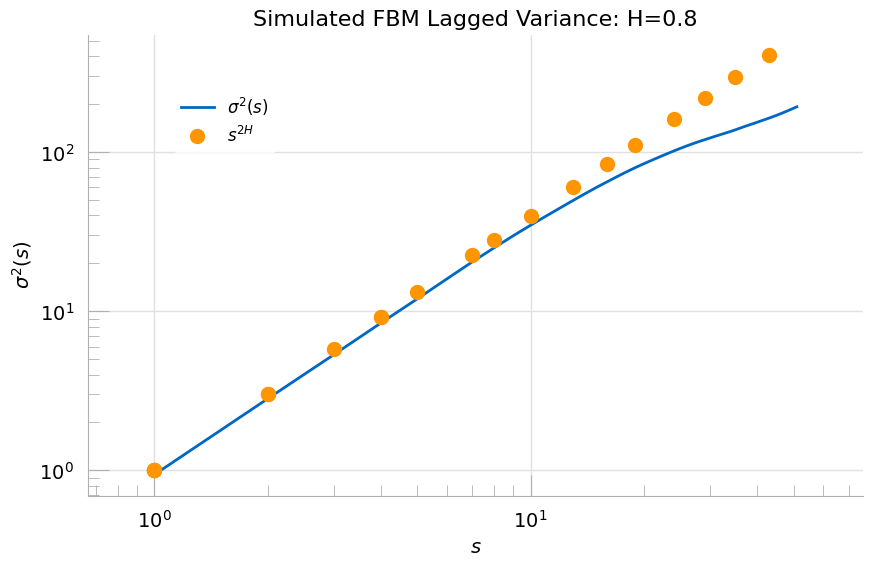

In [21]:
lag_var_plot(samples[2], H_vals[2], npts)

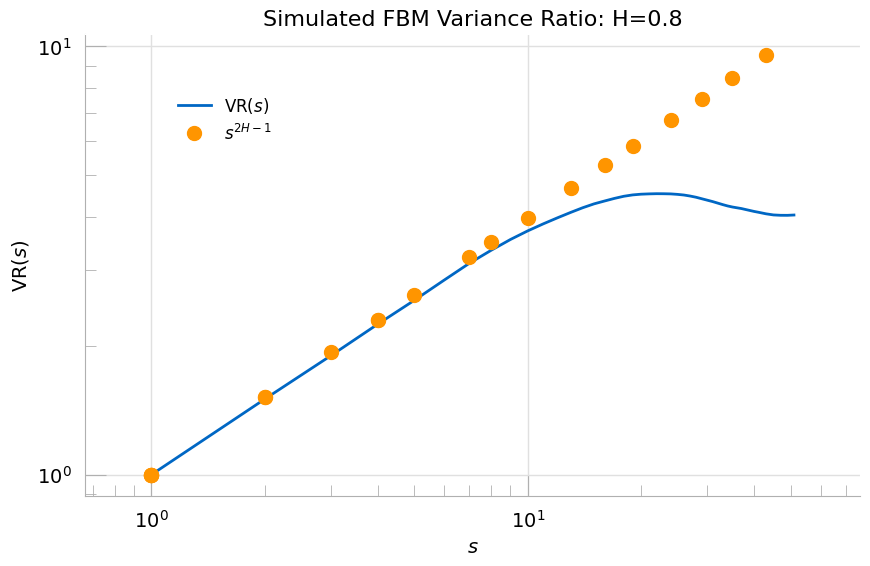

In [22]:
vr_plot(samples[2], H_vals[2], npts)

## Variance Ratio Test Comparison

In this section simulations that test the homoscedastic and heteroscedastic variance ratio test statistic are presented. It is seen that the results are not</br>
significantly different despite the greater cost of the heteroscedastic calculation. First large time series are</br>
analyzed followed by more realistic series lengths. A range of $H$ values is used.

In [23]:
npts = 2**16
s_vals = [2, 10, 100, 1000]
H_vals = [0.5, 0.3, 0.7]
t, samples = create(H_vals, npts)

### H = 0.5 

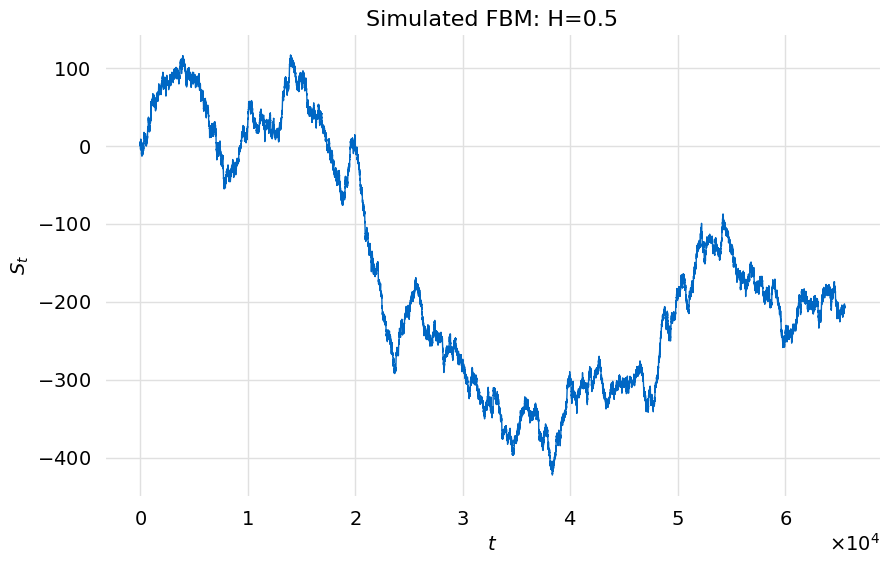

In [24]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [25]:
result, result_model = fbm.compute_vr_test(samples[0], HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  0.534 │    0.593 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  0.621 │    0.534 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  0.451 │    0.652 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  0.422 │    0.673 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  24 │  0

In [26]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "TWO_TAIL",
    "hyp_test_type": "BM",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "label": "$Z(s)$",
                "value": 0.5342010143641673,
                "hyp_test_id": "45028072-f79b-448d-8b65-752a3de808c9"
            },
            "pval": {
                "label": "$p-value$",
                "value": 0.5932024674154055,
                "hyp_test_id": "45028072-f79b-448d-8b65-752a3de808c9"
            },
            "params": [
                {
                    "label": "$s$",
                    "value": 4,
                    "hyp_test_id": "45028072-f79b-448d-8b65-752a3de808c9"
                }
            ],
            "sig": {
                "label": "10%",
                "value": 0.1,
                "hyp_test_id": "45028072-f79b-448d-8b65-752a3de808c9"
            },
            "lower": {
                "label": "$Z_L(s)$",
                "value": -1.64485362

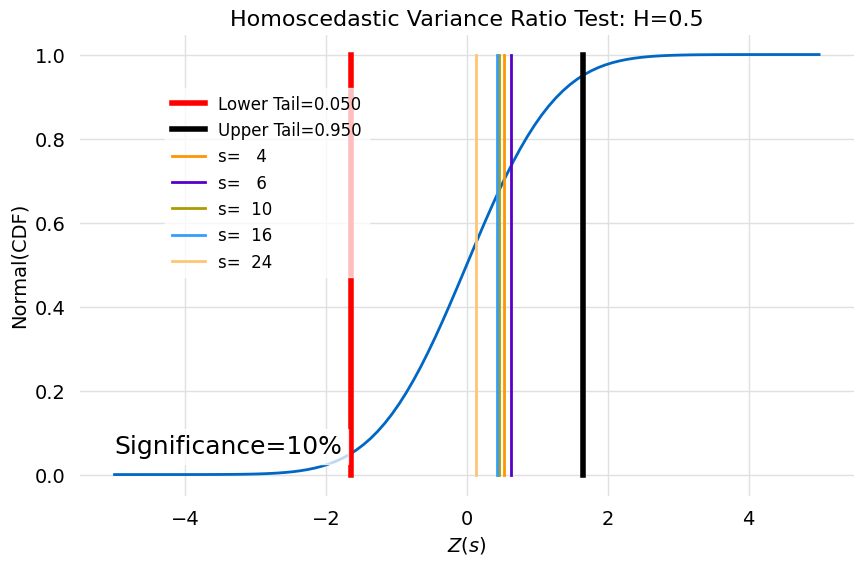

In [27]:
homo_test_stat_plot(result, H_vals[0])

In [28]:
result, result_model = fbm.compute_hetero_vr_test(samples[0], HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  0.534 │    0.593 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  0.622 │    0.534 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  0.451 │    0.652 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  0.422 │    0.673 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  24 │  0

In [29]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "TWO_TAIL",
    "hyp_test_type": "BM",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "label": "$Z(s)$",
                "value": 0.5341091384340669,
                "hyp_test_id": "9b746657-34df-4752-a1b2-75033070db56"
            },
            "pval": {
                "label": "$p-value$",
                "value": 0.5932660275783506,
                "hyp_test_id": "9b746657-34df-4752-a1b2-75033070db56"
            },
            "params": [
                {
                    "label": "$s$",
                    "value": 4,
                    "hyp_test_id": "9b746657-34df-4752-a1b2-75033070db56"
                }
            ],
            "sig": {
                "label": "10%",
                "value": 0.1,
                "hyp_test_id": "9b746657-34df-4752-a1b2-75033070db56"
            },
            "lower": {
                "label": "$Z_L(s)$",
                "value": -1.64485362

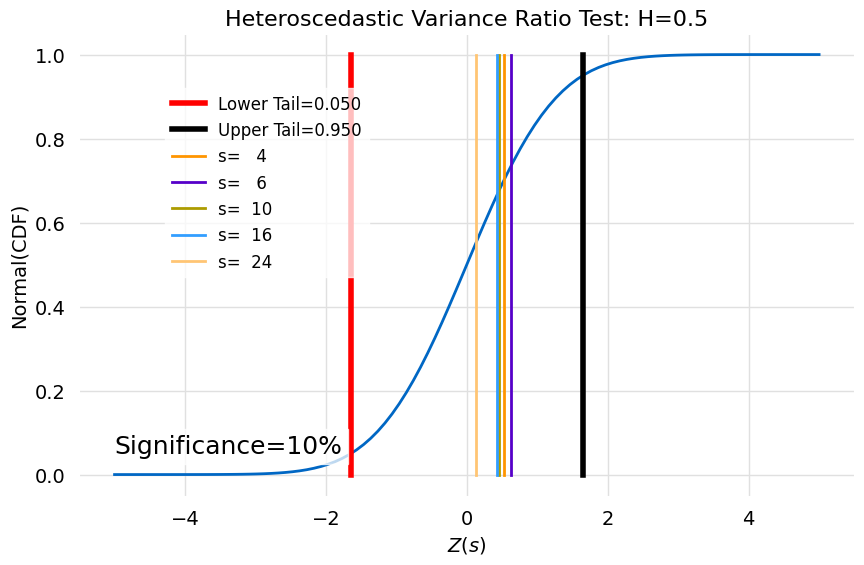

In [30]:
hetero_test_stat_plot(result, H_vals[0])

### H = 0.3

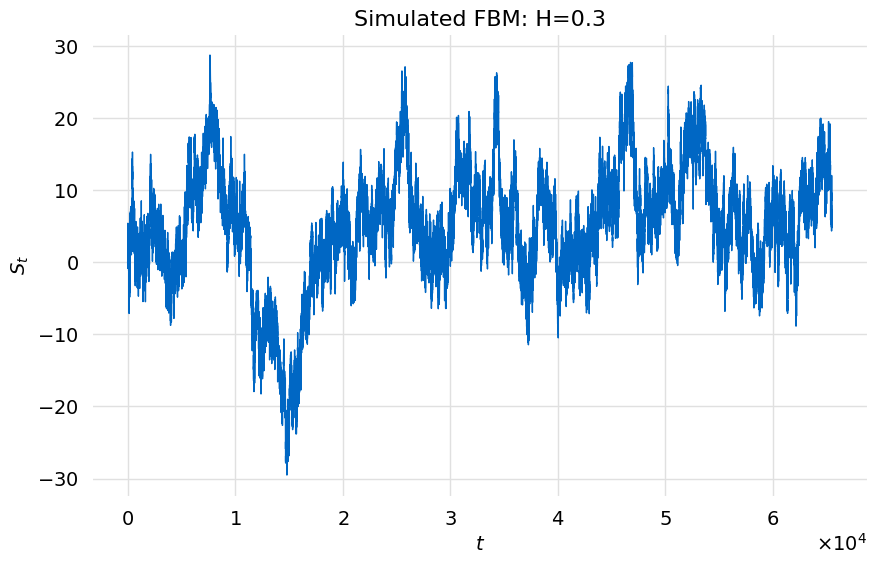

In [31]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [33]:
result, result_model = fbm.compute_vr_test(samples[1], HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤═════════╤══════════╤══════════╕
│   s │    Z(s) │   pvalue │ Result   │
╞═════╪═════════╪══════════╪══════════╡
│   4 │ -57.626 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│   6 │ -52.255 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  10 │ -45.497 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  16 │ -38.936 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤

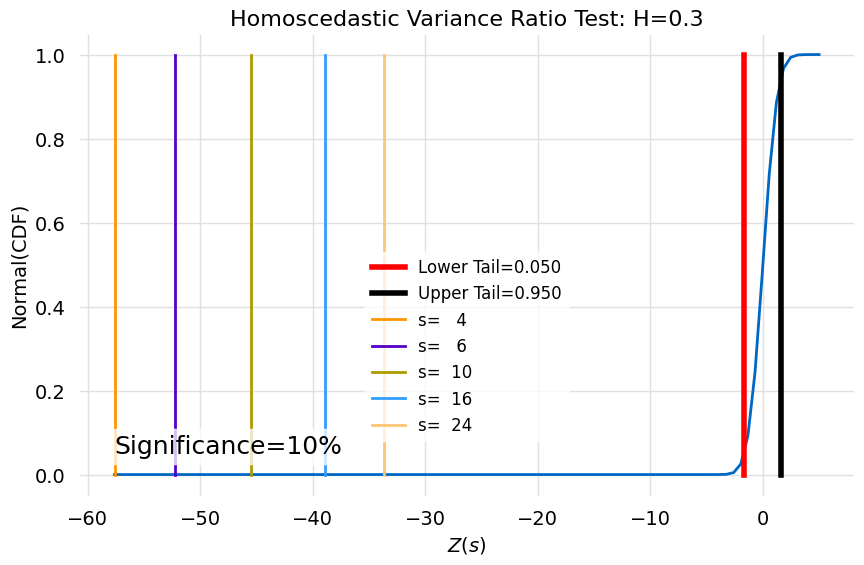

In [34]:
homo_test_stat_plot(result, H_vals[1])

In [35]:
result, result_model = fbm.compute_hetero_vr_test(samples[1], HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤═════════╤══════════╤══════════╕
│   s │    Z(s) │   pvalue │ Result   │
╞═════╪═════════╪══════════╪══════════╡
│   4 │ -55.583 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│   6 │ -50.905 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  10 │ -44.734 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  16 │ -38.494 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤

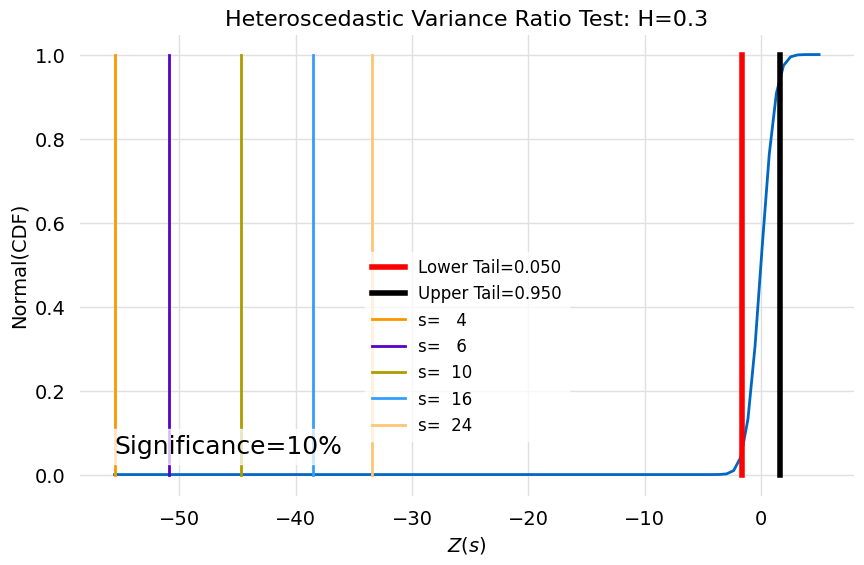

In [36]:
hetero_test_stat_plot(result, H_vals[1])

### H=0.7

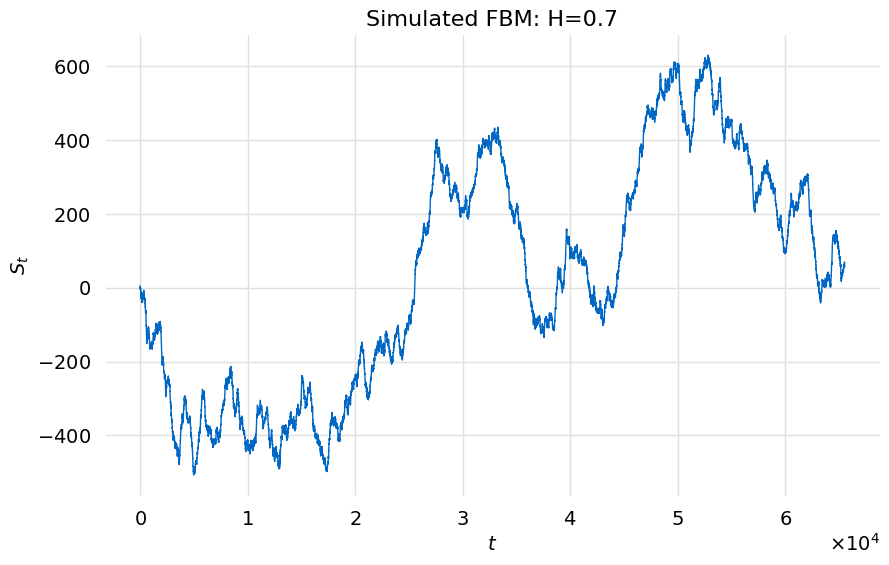

In [37]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [38]:
result, result_model = fbm.compute_vr_test(samples[2], HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤═════════╤══════════╤══════════╕
│   s │    Z(s) │   pvalue │ Result   │
╞═════╪═════════╪══════════╪══════════╡
│   4 │ 100.212 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│   6 │ 107.451 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  10 │ 113.987 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  16 │ 118.033 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤

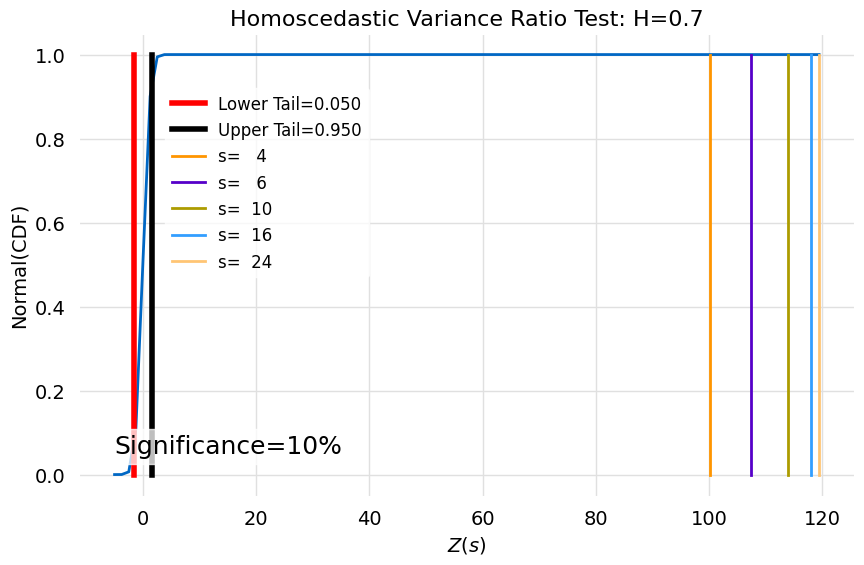

In [39]:
homo_test_stat_plot(result, H_vals[2])

In [40]:
result, result_model = fbm.compute_hetero_vr_test(samples[2], HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤═════════╤══════════╤══════════╕
│   s │    Z(s) │   pvalue │ Result   │
╞═════╪═════════╪══════════╪══════════╡
│   4 │  93.358 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│   6 │ 101.487 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  10 │ 109.36  │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  16 │ 114.544 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤

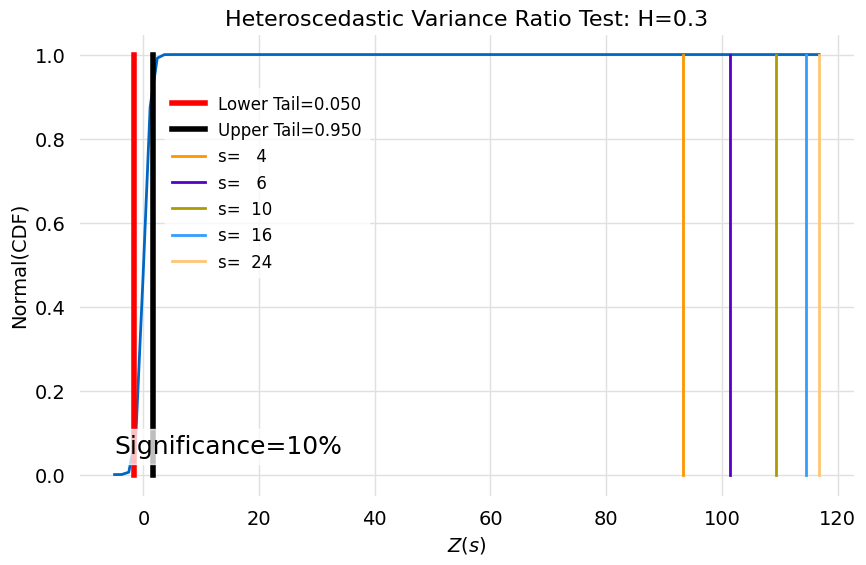

In [41]:
hetero_test_stat_plot(result, H_vals[1])

### Values Near H=0.5

The performance of the homoscedastic and heteroscedastic for values near $H=0.5$ is evaluated.

In [42]:
npts = 2**16
s_vals = [2, 10, 100, 1000]
H_vals = [0.475, 0.49, 0.51, 0.525]
t, samples = create(H_vals, npts)

#### H=0.51

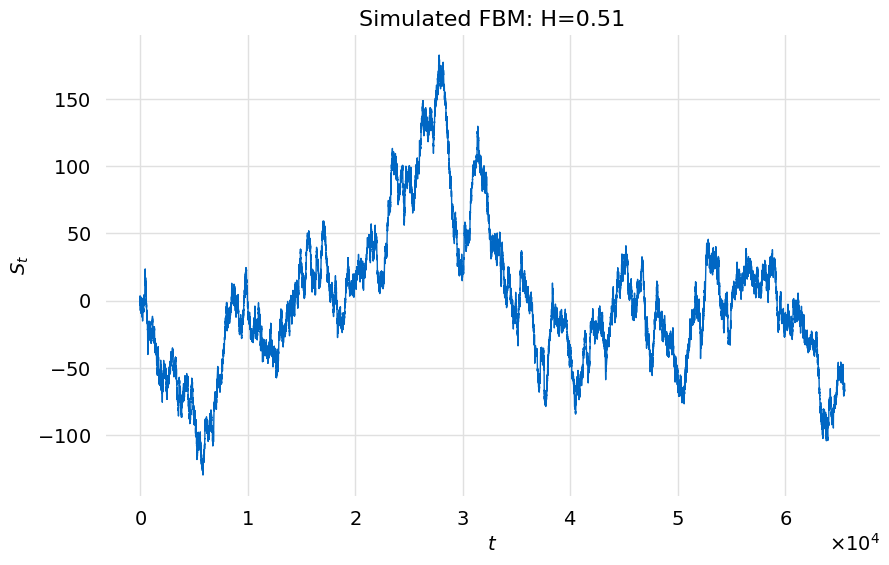

In [43]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [44]:
result, result_model = fbm.compute_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │  3.82  │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │  4.903 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │  2.009 │    0.044 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │  1.02  │    0.308 │ Passed   │
╘══════╧════════╧══════════╧══════════╛

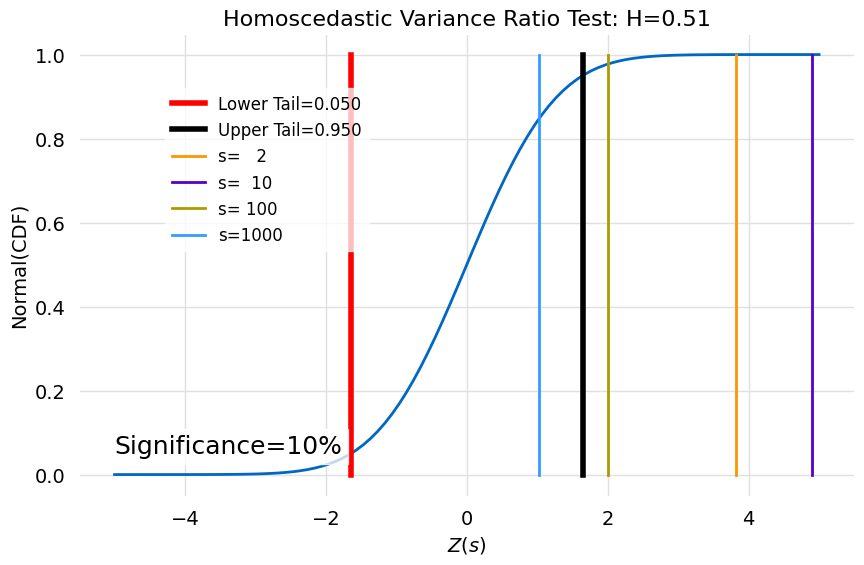

In [45]:
homo_test_stat_plot(result, H_vals[2])

In [46]:
result, result_model = fbm.compute_hetero_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │  3.832 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │  4.903 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │  2.008 │    0.045 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │  1.022 │    0.307 │ Passed   │
╘══════╧════════╧══════════╧══════════╛

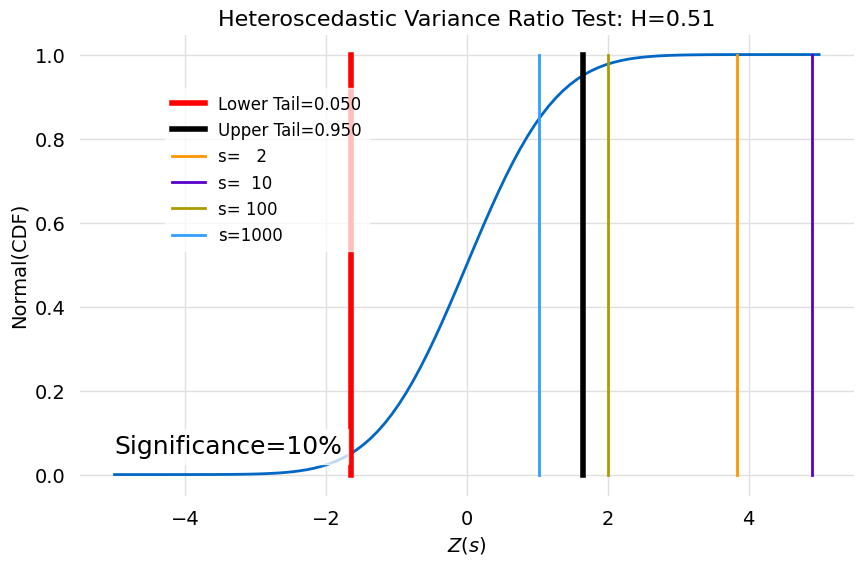

In [47]:
hetero_test_stat_plot(result, H_vals[2])

#### H=0.49

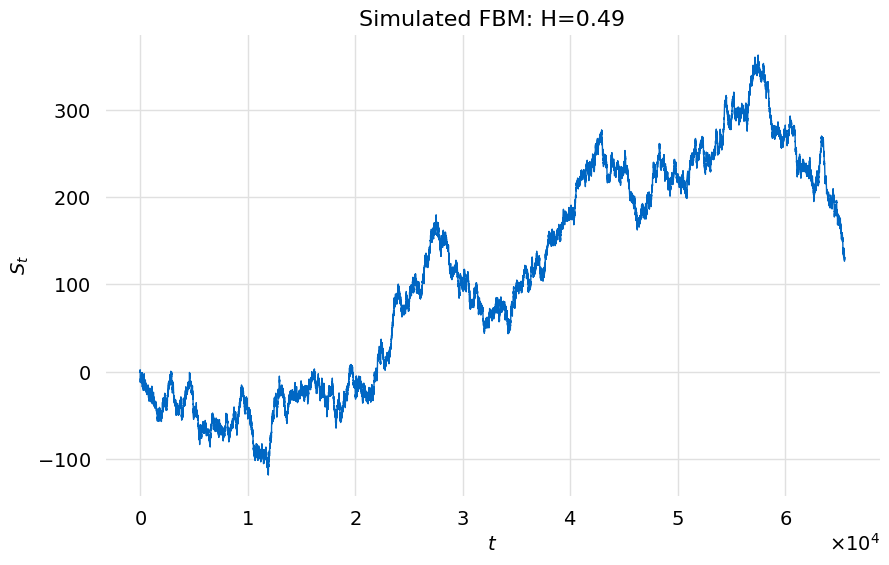

In [48]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [49]:
result, result_model = fbm.compute_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │ -4.065 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │ -2.021 │    0.043 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │ -1.9   │    0.057 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │ -0.969 │    0.332 │ Passed   │
╘══════╧════════╧══════════╧══════════╛

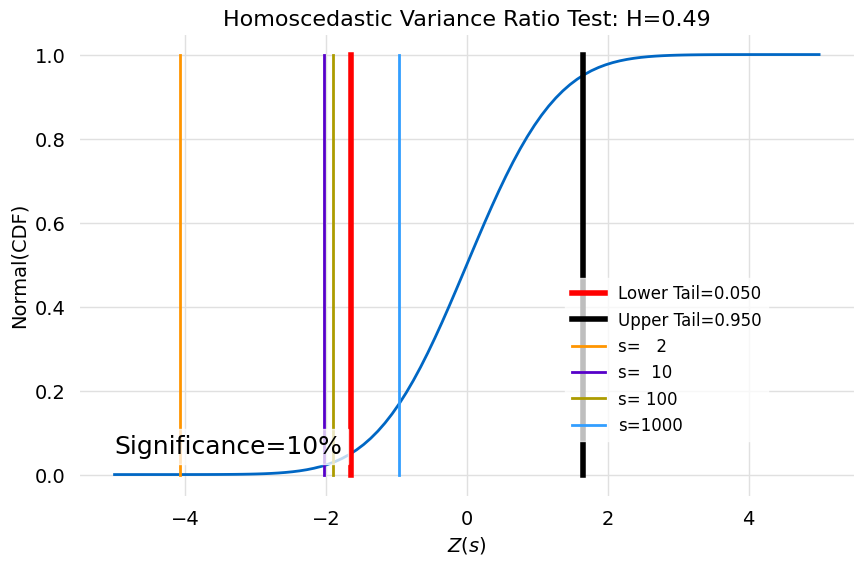

In [50]:
homo_test_stat_plot(result, H_vals[1])

In [51]:
result, result_model = fbm.compute_hetero_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │ -4.088 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │ -2.028 │    0.043 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │ -1.901 │    0.057 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │ -0.971 │    0.332 │ Passed   │
╘══════╧════════╧══════════╧══════════╛

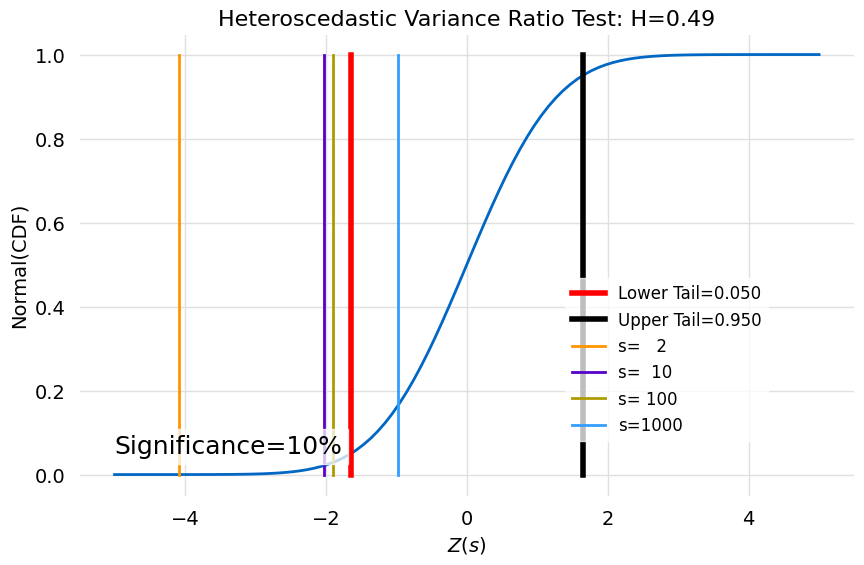

In [52]:
hetero_test_stat_plot(result, H_vals[1])

#### H=0.475

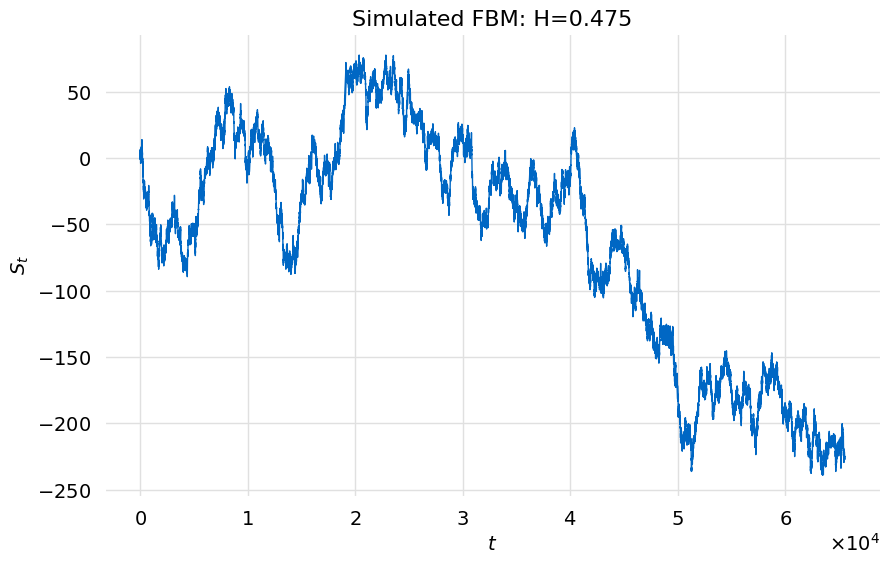

In [53]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [54]:
result, result_model = fbm.compute_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │ -9.187 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │ -8.076 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │ -3.988 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │ -1.319 │    0.187 │ Passed   │
╘══════╧════════╧══════════╧══════════╛

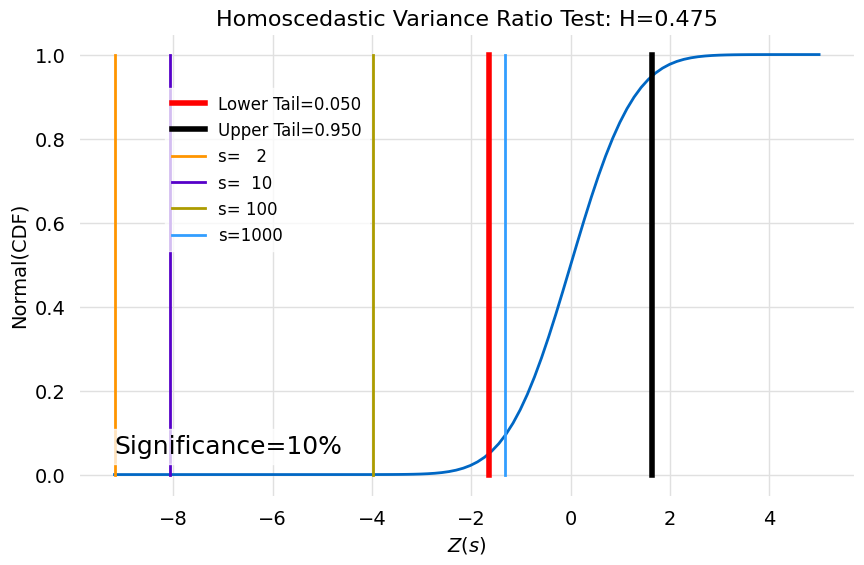

In [55]:
homo_test_stat_plot(result, H_vals[0])

In [56]:
result, result_model = fbm.compute_hetero_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │ -9.159 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │ -8.066 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │ -3.985 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │ -1.322 │    0.186 │ Passed   │
╘══════╧════════╧══════════╧══════════╛

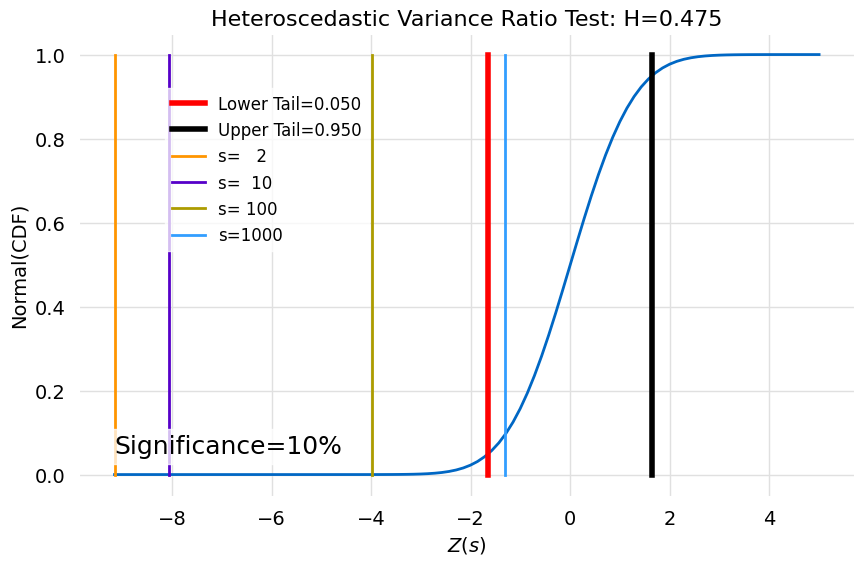

In [57]:
hetero_test_stat_plot(result, H_vals[0])

### Small Sample Size

In [58]:
npts = 2**9
s_vals = [4, 10, 25, 50, 100]
H_vals = [0.5, 0.7, 0.3]
t, samples = create(H_vals, npts)

#### H=0.5

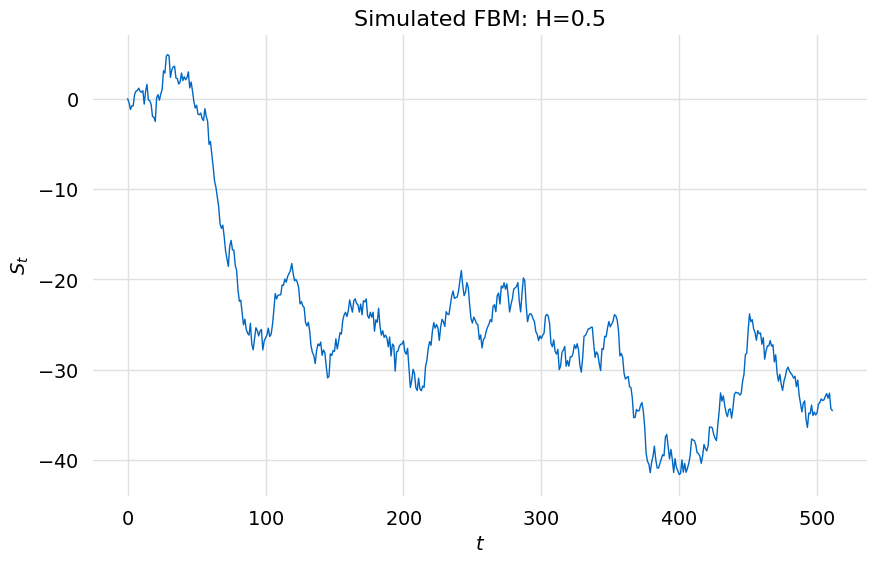

In [59]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [60]:
result, result_model = fbm.compute_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  0.886 │    0.376 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  1.982 │    0.048 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  2.995 │    0.003 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  1.914 │    0.056 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │  0

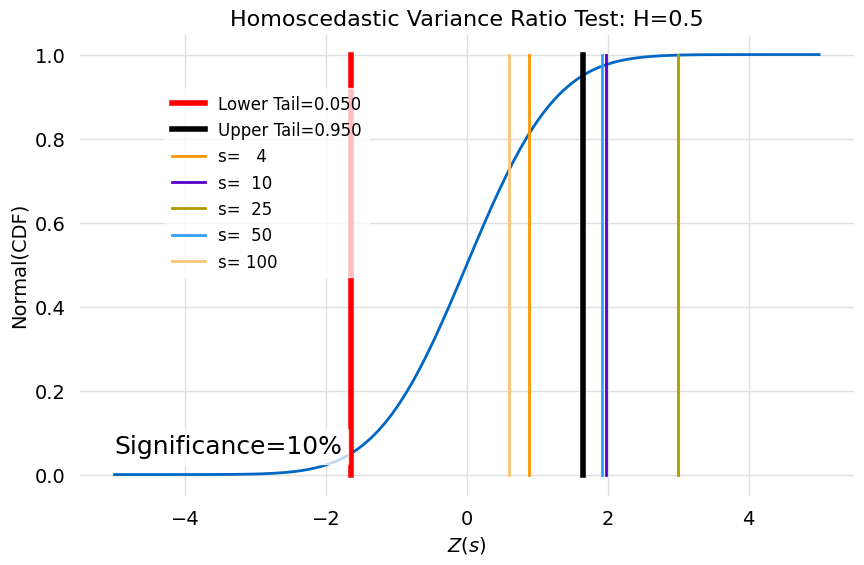

In [61]:
homo_test_stat_plot(result, H_vals[0])

In [62]:
result, result_model = fbm.compute_hetero_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  0.903 │    0.367 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  2.03  │    0.042 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  3.048 │    0.002 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  1.944 │    0.052 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │  0

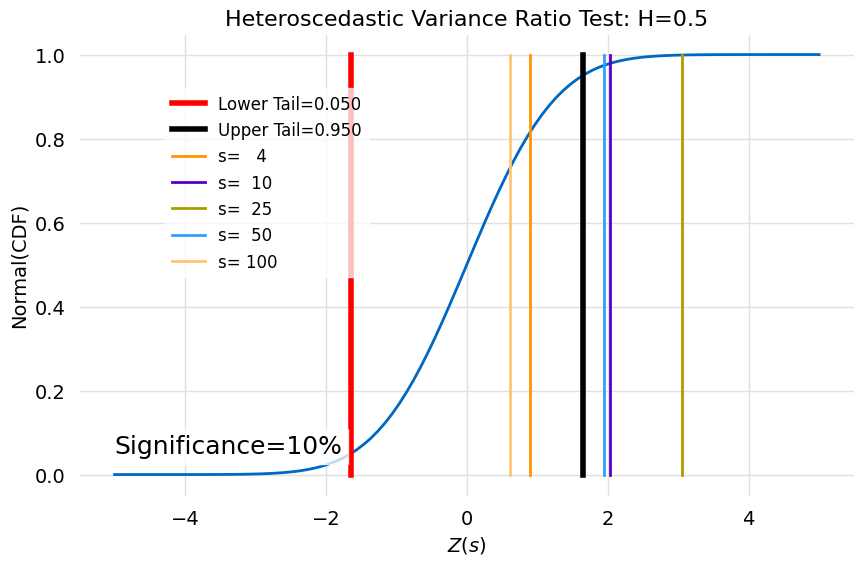

In [64]:
hetero_test_stat_plot(result, H_vals[0])

#### H=0.7

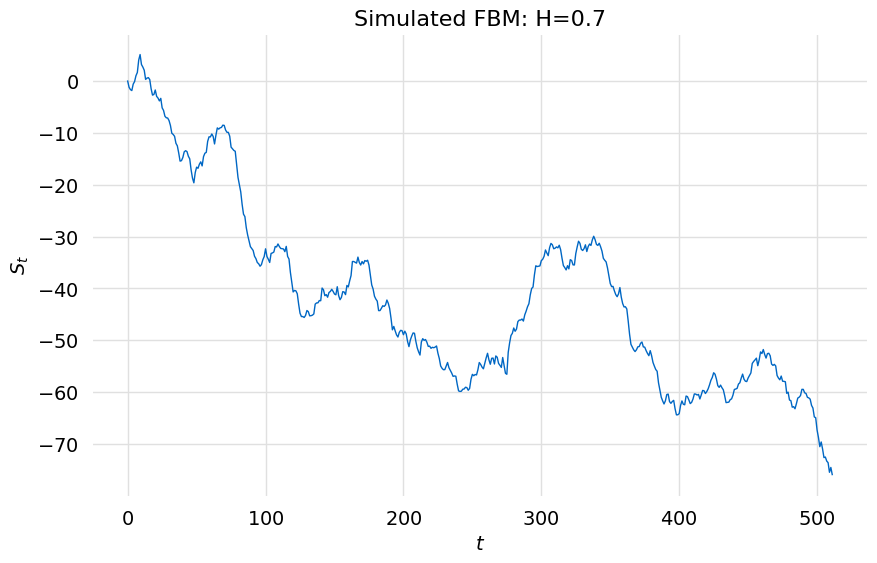

In [65]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [66]:
result, result_model = fbm.compute_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  8.427 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ 10.745 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  9.986 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  8.434 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │  5

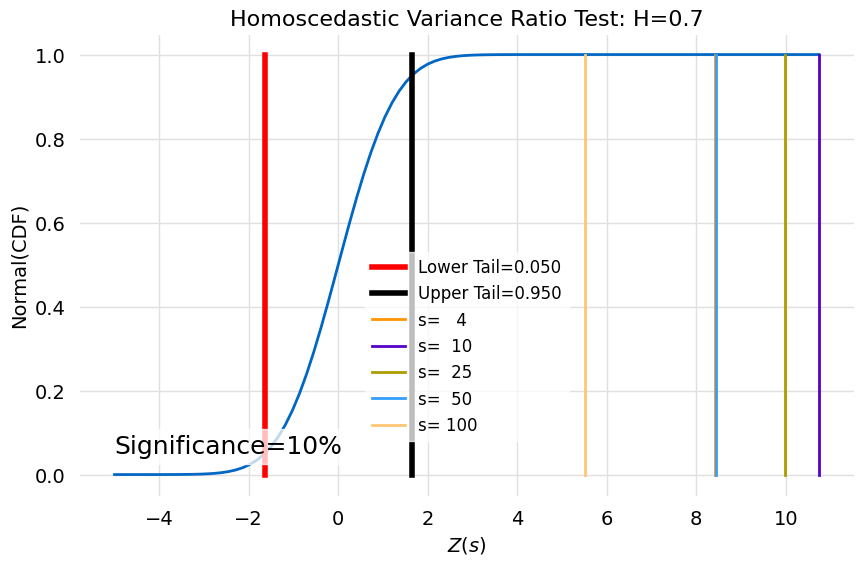

In [67]:
homo_test_stat_plot(result, H_vals[1])

In [68]:
result, result_model = fbm.compute_hetero_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  7.857 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ 10.304 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  9.98  │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  8.553 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │  5

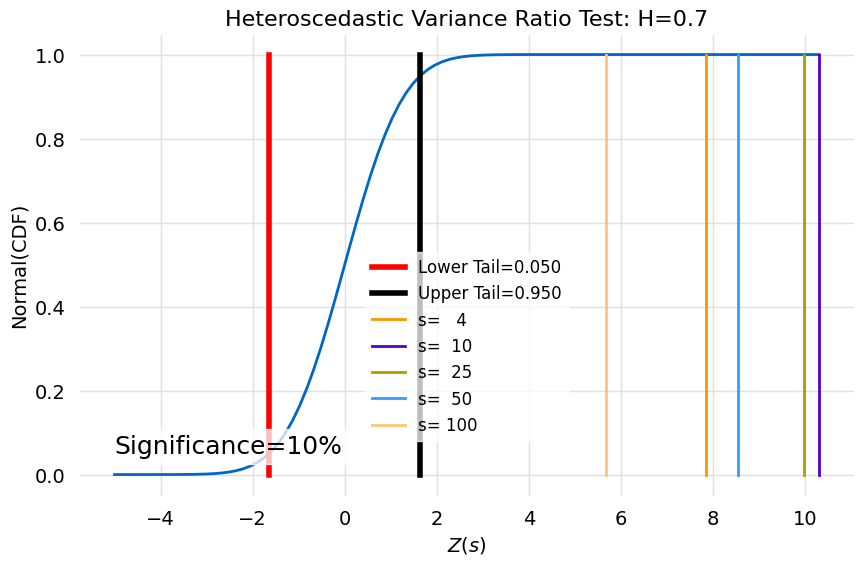

In [69]:
hetero_test_stat_plot(result, H_vals[1])

#### H=0.3

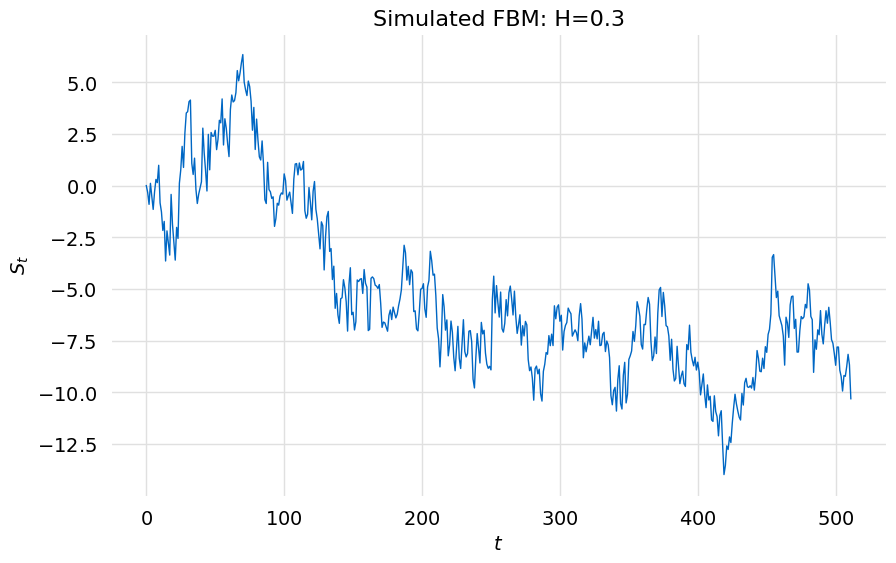

In [70]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [71]:
result, result_model = fbm.compute_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -4.542 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -3.776 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -2.673 │    0.008 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -2.086 │    0.037 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │ -1

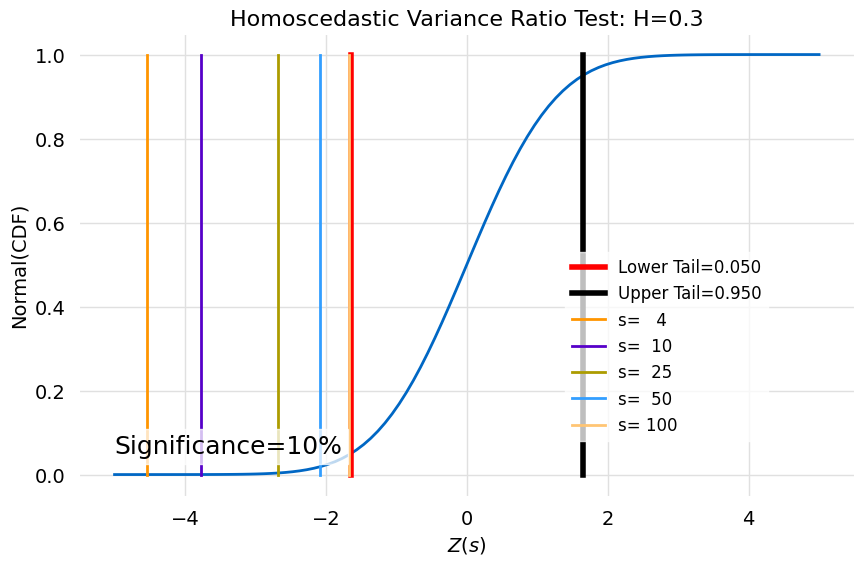

In [72]:
homo_test_stat_plot(result, H_vals[2])

In [73]:
result, result_model = fbm.compute_hetero_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -4.663 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -3.758 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -2.625 │    0.009 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -2.069 │    0.039 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │ -1

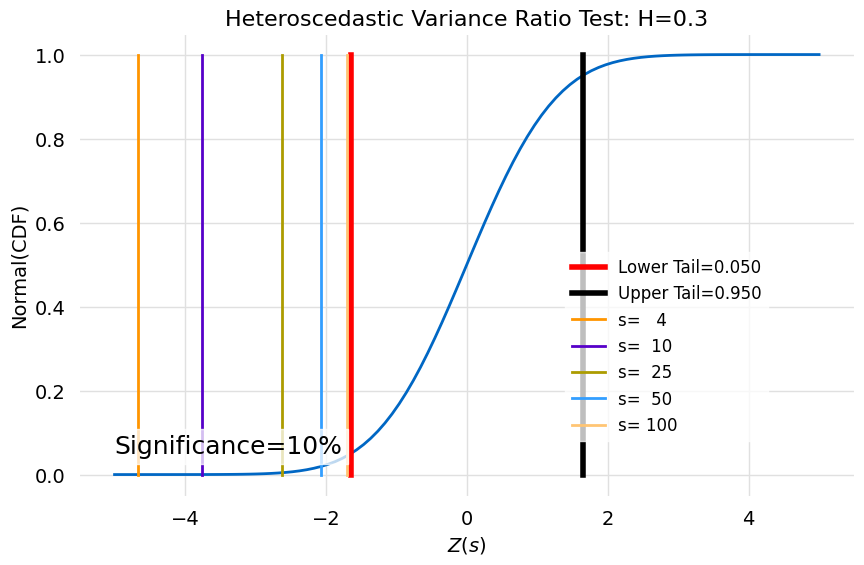

In [74]:
hetero_test_stat_plot(result, H_vals[2])

### Values Near H=0.5

In [75]:
npts = 2**9
s_vals = [2, 4, 10, 25, 50]
H_vals = [0.49, 0.45, 0.4, 0.51, 0.55]
t, samples = create(H_vals, npts)

#### H=0.49

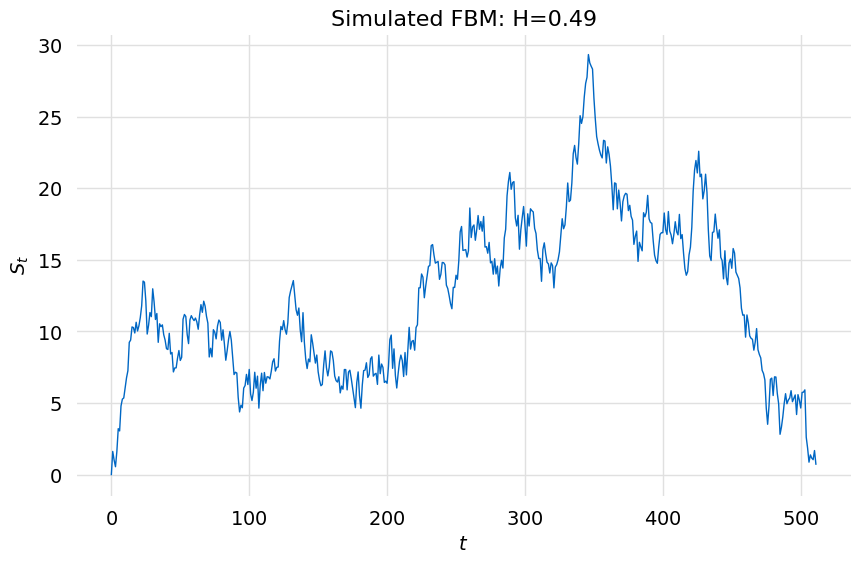

In [76]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [77]:
result, result_model = fbm.compute_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -1.688 │    0.091 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -1.271 │    0.204 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -1.161 │    0.245 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -0.867 │    0.386 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -0

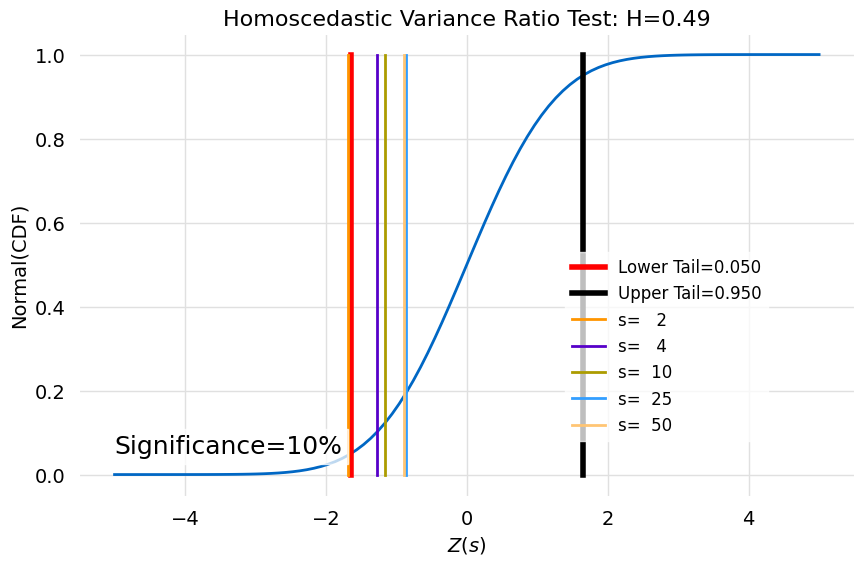

In [78]:
homo_test_stat_plot(result, H_vals[0])

In [79]:
result, result_model = fbm.compute_hetero_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -1.724 │    0.085 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -1.306 │    0.192 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -1.181 │    0.237 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -0.878 │    0.38  │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -0

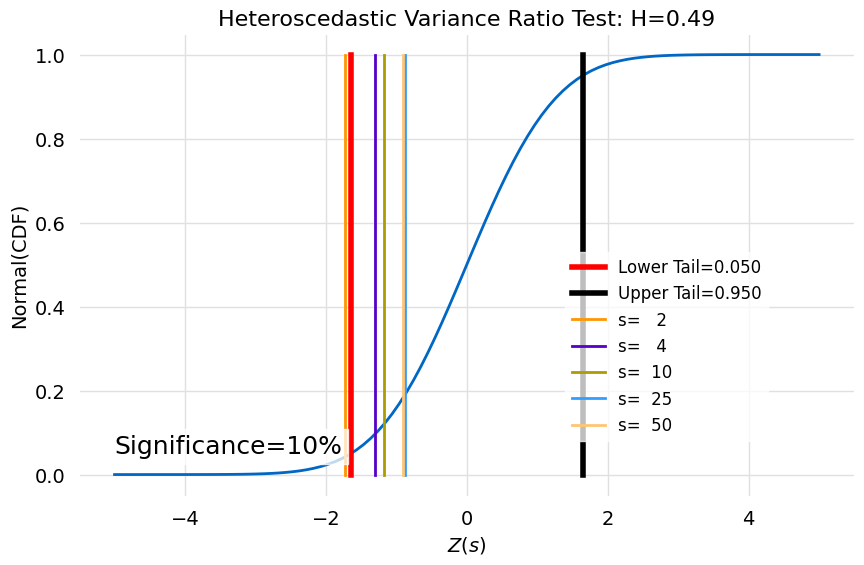

In [80]:
hetero_test_stat_plot(result, H_vals[0])

#### H=0.45

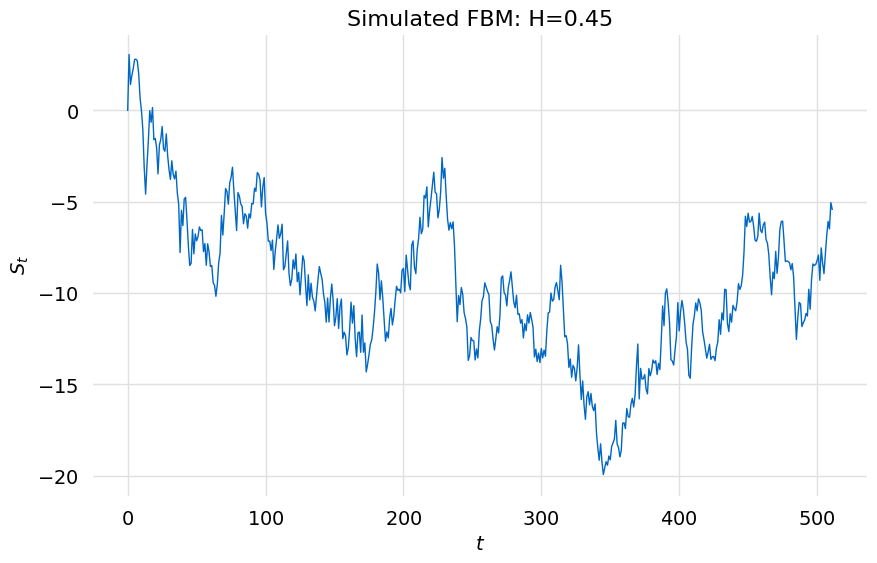

In [81]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [82]:
result, result_model = fbm.compute_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -2.797 │    0.005 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -2.299 │    0.021 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -2.312 │    0.021 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -1.605 │    0.108 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -1

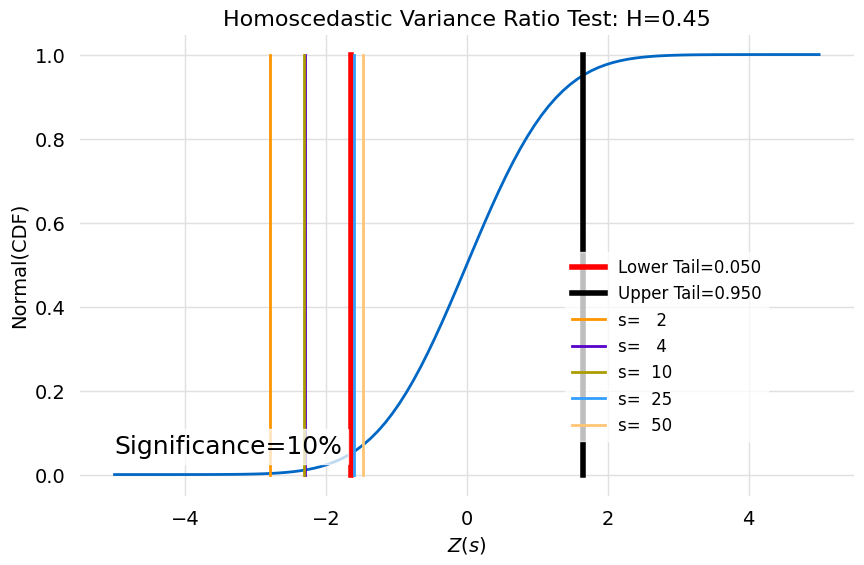

In [83]:
homo_test_stat_plot(result, H_vals[1])

In [84]:
result, result_model = fbm.compute_hetero_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -2.599 │    0.009 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -2.178 │    0.029 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -2.289 │    0.022 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -1.616 │    0.106 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -1

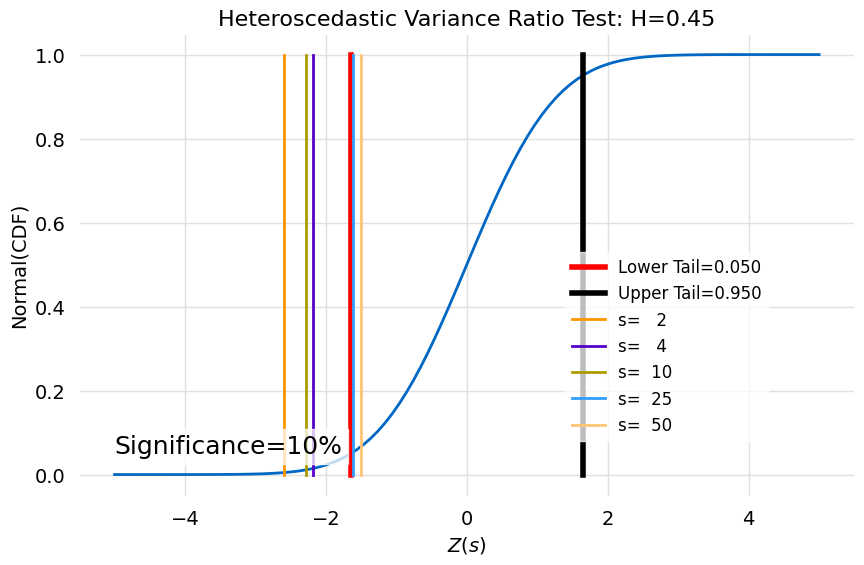

In [85]:
hetero_test_stat_plot(result, H_vals[1])

#### H=0.4

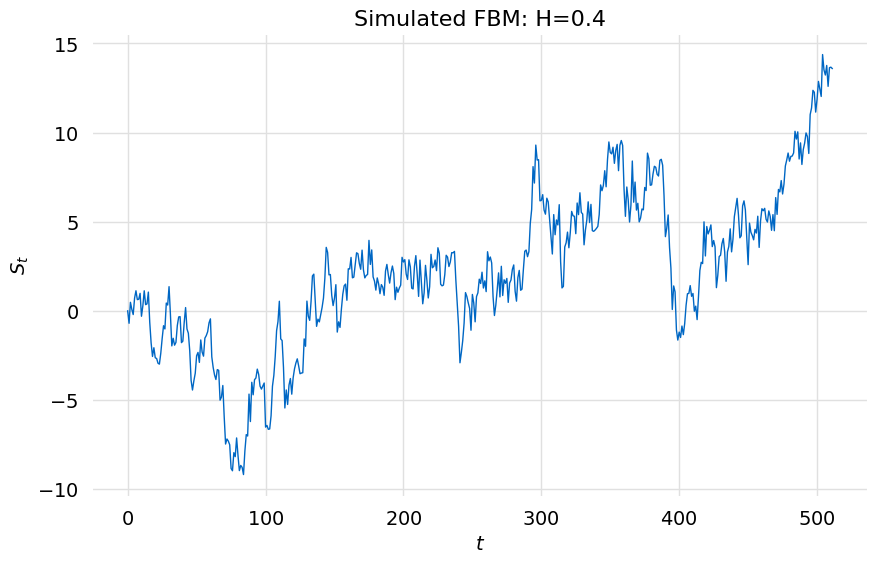

In [86]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [87]:
result, result_model = fbm.compute_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -3.13  │    0.002 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -2.962 │    0.003 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -2.469 │    0.014 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -2.293 │    0.022 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -1

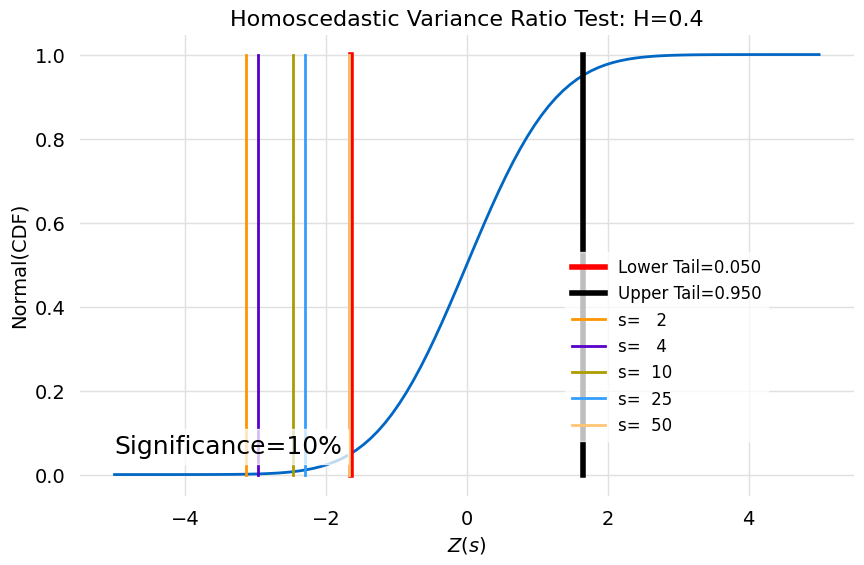

In [88]:
homo_test_stat_plot(result, H_vals[2])

In [89]:
result, result_model = fbm.compute_hetero_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -3.025 │    0.002 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -2.891 │    0.004 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -2.438 │    0.015 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -2.303 │    0.021 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -1

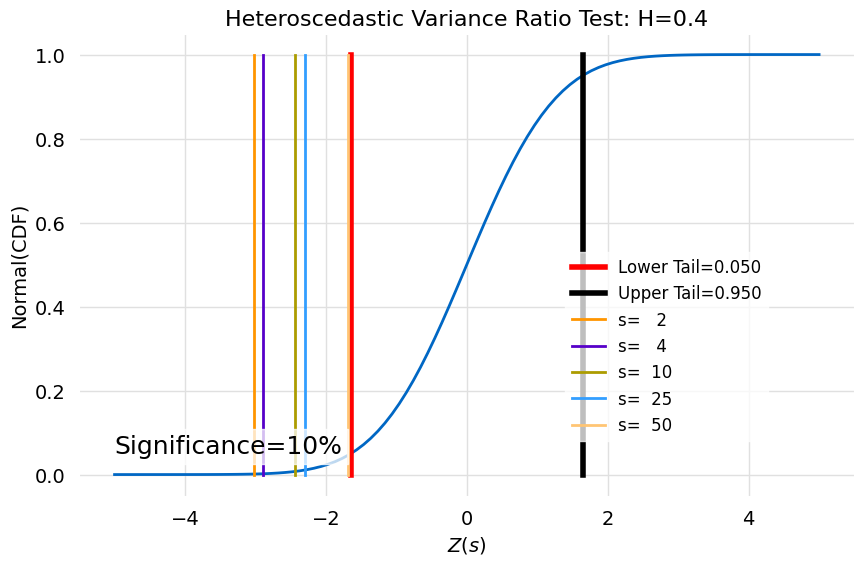

In [90]:
hetero_test_stat_plot(result, H_vals[2])

#### H=0.51

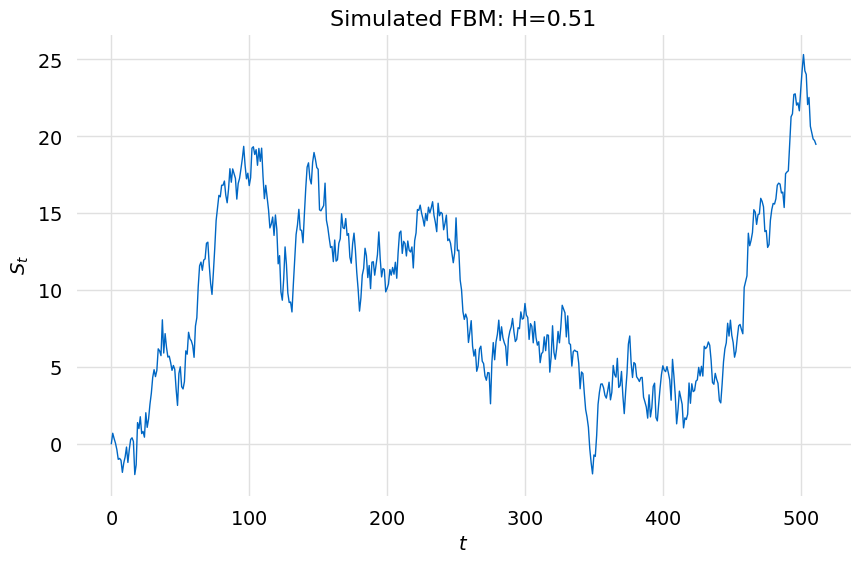

In [91]:
title = f"Simulated FBM: H={H_vals[3]}"
curve(samples[3], t[3], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [92]:
result, result_model = fbm.compute_vr_test(samples[3], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -1.033 │    0.302 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -1.11  │    0.267 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -1     │    0.317 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -0.441 │    0.659 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -0

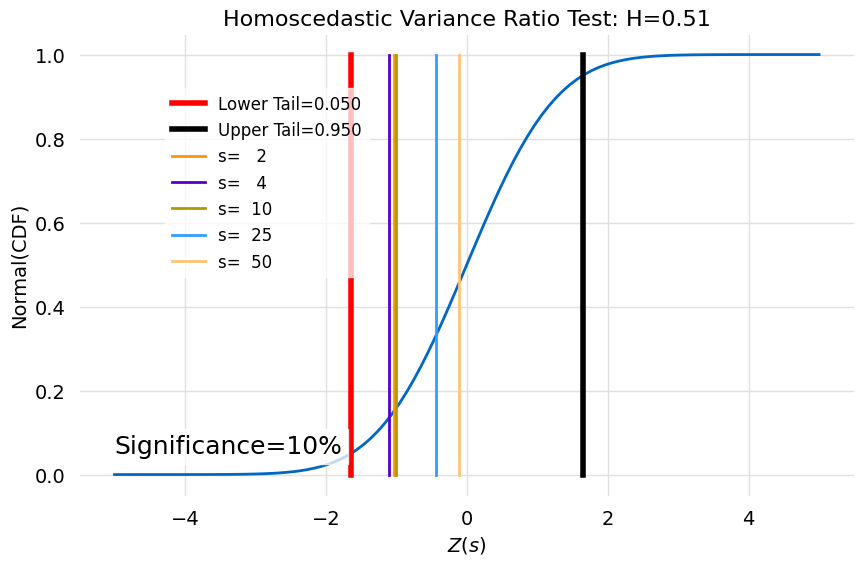

In [93]:
homo_test_stat_plot(result, H_vals[3])

In [94]:
result, result_model = fbm.compute_hetero_vr_test(samples[3], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -1.041 │    0.298 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -1.104 │    0.27  │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -1.001 │    0.317 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -0.445 │    0.656 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -0

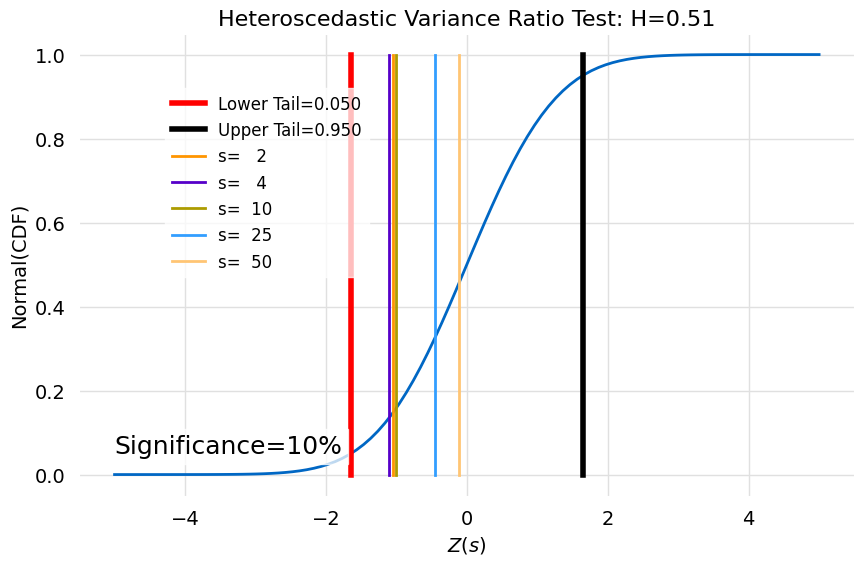

In [95]:
hetero_test_stat_plot(result, H_vals[3])

#### H=0.55

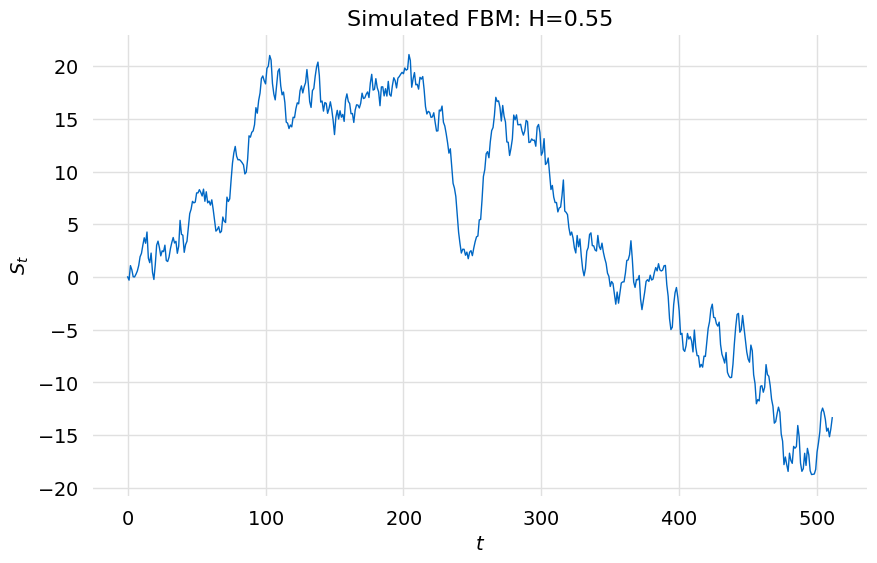

In [96]:
title = f"Simulated FBM: H={H_vals[4]}"
curve(samples[4], t[4], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [97]:
result, result_model = fbm.compute_vr_test(samples[4], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │  2.729 │    0.006 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │  2.38  │    0.017 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  1.796 │    0.072 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  1.075 │    0.282 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  0

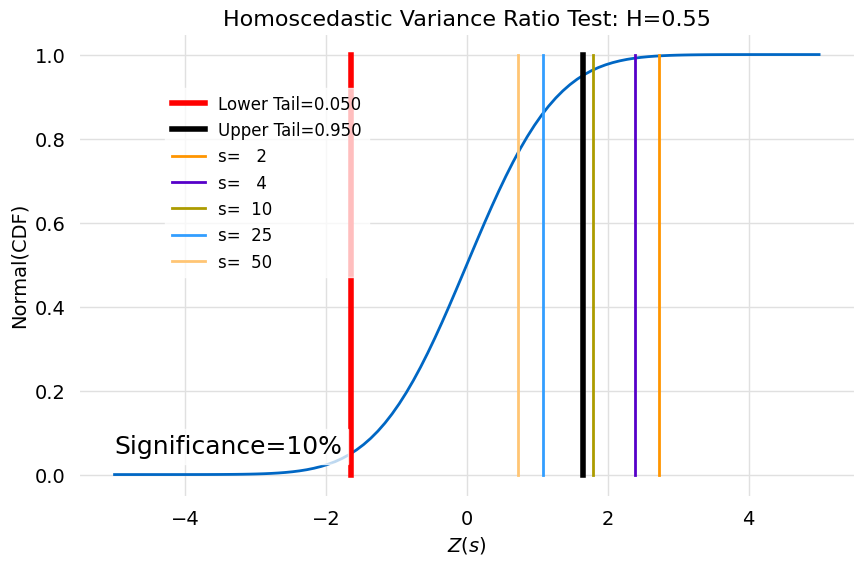

In [98]:
homo_test_stat_plot(result, H_vals[4])

In [99]:
result, result_model = fbm.compute_hetero_vr_test(samples[4], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │  2.838 │    0.005 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │  2.444 │    0.015 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  1.819 │    0.069 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  1.092 │    0.275 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  0

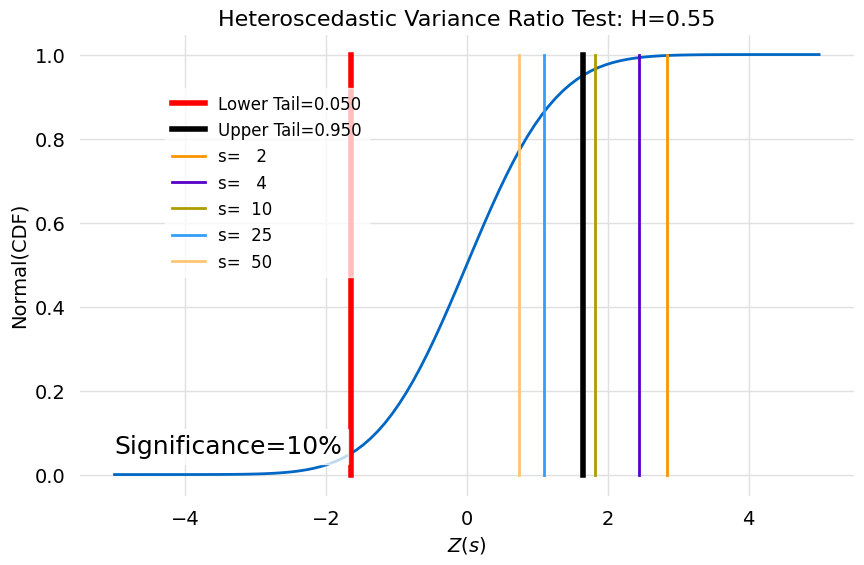

In [100]:
hetero_test_stat_plot(result, H_vals[4])

## Variance Ratio Test

Here the performance of the variance ratio test is evaluated. In the previous analysis the performance of the homoscedastic test was not significantly different</br>
than the heteroscedastic test. Since the homoscedastic test is much faster it is used. The values of the variance ratio test statistic for $0 < H < \frac{1}{2}$, $H=\frac{1}{2}$</br>
and $\frac{1}{2} < H < 1$ respectively satisfy $Z(s) < 0$, $Z(s) = 0$ and $Z(s) > 0$. This follows from the variance ratio, $\text{VR}(s)$ satisfying $0 < \text{VR}(s) < 1$, $\text{VR}(s)=1$ and $\text{VR}(s) > 1$</br>
in that same regions. Plots of $Z(s)$ for these regions are shown below. It is seen for $0 < H < \frac{1}{2}$ that $Z(s)$ is an increasing function of $s$ and for $\frac{1}{2} < H < 1$</br>
$Z(s)$ has a more complex behavior but is increasing for smaller values of $s$. It follows that eventually for some value of $s$ the test will likely fail. This makes interpreting the tests</br> 
results somewhat difficult. In the previous analysis where $\text{VR}(s)$ was compared to $\sigma s^{2H-1}$ it was seen that for a series with $2^9$ points the the two values agreed well for</br>
up to $s=2^8$. This motivates evaluating $Z(s)$ in regions where it is always increasing using a sequence of values of $s$ satisfying $s \le 25$. For this range the agreement between $\text{VR}(s)$</br>
and $\sigma s^{2H-1}$ was best. $Z(s)$ is evaluated for each $s$ and the result is pass if at least one test passes and failed otherwise.

### $H \le \frac{1}{2}$

In [101]:
npts = 2**9
s_min=2.0
s_max=npts/2
s_npts=int(s_max - s_min + 1)

In [102]:
H_vals = [0.1, 0.2, 0.3, 0.4, 0.5]
t, samples = create(H_vals, npts)
func = lambda t, data, **kwargs: fbm.compute_vr_scan(data, **kwargs)
_, vr = apply_to_parameter_scan(func, t, samples, smin=s_min, smax=s_max, npts=s_npts, linear=True)

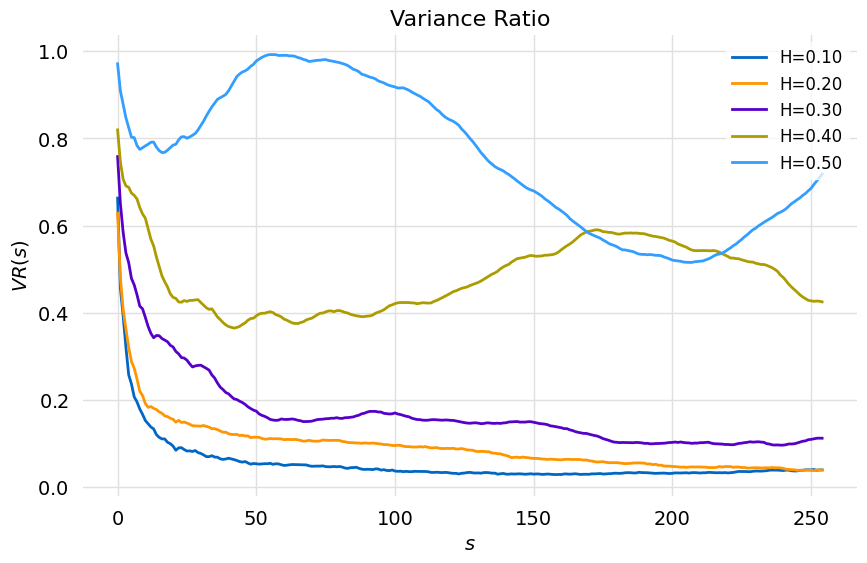

In [103]:
title = r"Variance Ratio"
comparison(vr, title=title, labels=H_labels(H_vals), xlabel=r"$s$", ylabel=r"$VR(s)$")

### $H \ge \frac{1}{2}$

In [104]:
H_vals = [0.5, 0.6, 0.7, 0.8, 0.89]
t, samples = create(H_vals, npts)
func = lambda t, data, **kwargs: fbm.compute_vr_scan(data, **kwargs)
_, vr = apply_to_parameter_scan(func, t, samples, smin=s_min, smax=s_max, npts=s_npts, linear=True)

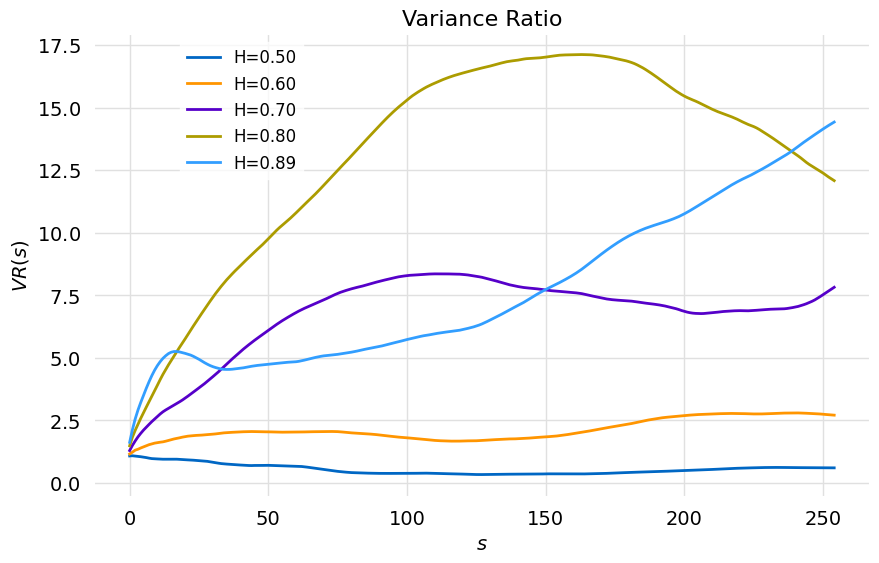

In [105]:
title = r"Variance Ratio"
comparison(vr, title=title, labels=H_labels(H_vals), xlabel=r"$s$", ylabel=r"$VR(s)$")

### $H = 0.5$

Here a two tailed test for brownian motion is performed. This test is successful if the result is **PASSED**

In [112]:
H=0.5
t, samples = fbm.create_fft_source(H=H, npts=npts)
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -0.554 │    0.58  │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -1.498 │    0.134 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -1.83  │    0.067 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -1.844 │    0.065 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  24 │ -2

In [113]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "TWO_TAIL",
    "hyp_test_type": "BM",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "label": "$Z(s)$",
                "value": -0.5539479876627191,
                "hyp_test_id": "fa6a2d58-7efc-45bf-942e-904f81d1f89d"
            },
            "pval": {
                "label": "$p-value$",
                "value": 0.5796144421876805,
                "hyp_test_id": "fa6a2d58-7efc-45bf-942e-904f81d1f89d"
            },
            "params": [
                {
                    "label": "$s$",
                    "value": 4,
                    "hyp_test_id": "fa6a2d58-7efc-45bf-942e-904f81d1f89d"
                }
            ],
            "sig": {
                "label": "10%",
                "value": 0.1,
                "hyp_test_id": "fa6a2d58-7efc-45bf-942e-904f81d1f89d"
            },
            "lower": {
                "label": "$Z_L(s)$",
                "value": -1.6448536

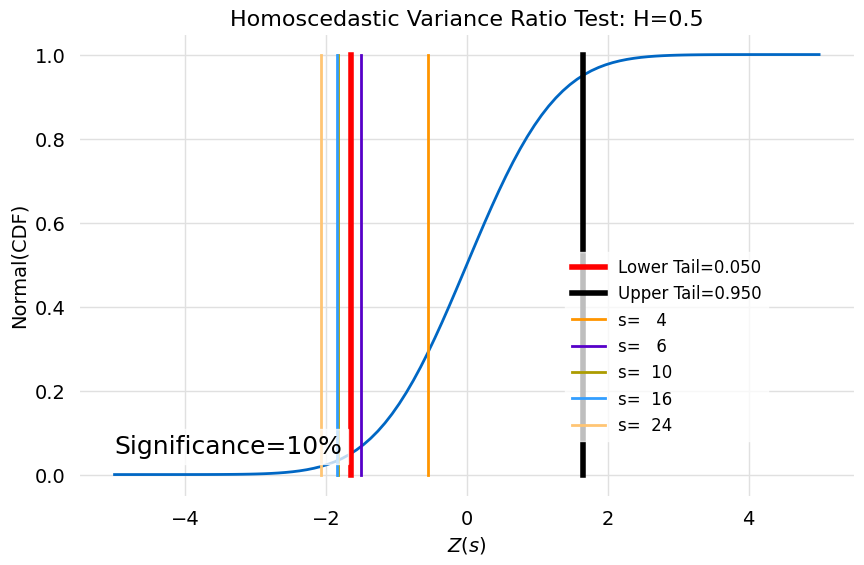

In [114]:
homo_test_stat_plot(result, H)

In [115]:
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.FBM_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.UPPER_TAIL        │
├──────────────────────┼──────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_AUTO_CORR │
├──────────────────────┼──────────────────────────────────┤
│ Significance         │ 10%                              │
├──────────────────────┼──────────────────────────────────┤
│ Upper Critical Value │ 1.282                            │
╘══════════════════════╧══════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -0.554 │    0.71  │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -1.498 │    0.933 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -1.83  │    0.966 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -1.844 │    0.967 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  24 │ -2.07  │    0.981 │ Pas

In [116]:
print(result_model.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "UPPER_TAIL",
    "hyp_test_type": "AUTO_CORR",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "label": "$Z(s)$",
                "value": -0.5539479876627191,
                "hyp_test_id": "af049a7c-5488-47f8-a298-63a89ef7b383"
            },
            "pval": {
                "label": "$p-value$",
                "value": 0.7101927789061597,
                "hyp_test_id": "af049a7c-5488-47f8-a298-63a89ef7b383"
            },
            "params": [
                {
                    "label": "$s$",
                    "value": 4,
                    "hyp_test_id": "af049a7c-5488-47f8-a298-63a89ef7b383"
                }
            ],
            "sig": {
                "label": "10%",
                "value": 0.1,
                "hyp_test_id": "af049a7c-5488-47f8-a298-63a89ef7b383"
            },
            "lower": null,
            "upper": {
                "label": "$Z_U(s)$",

In [119]:
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.FBM_NEG_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.LOWER_TAIL            │
├──────────────────────┼──────────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_NEG_AUTO_CORR │
├──────────────────────┼──────────────────────────────────────┤
│ Significance         │ 10%                                  │
├──────────────────────┼──────────────────────────────────────┤
│ Lower Critical Value │ -1.282                               │
╘══════════════════════╧══════════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -0.554 │    0.29  │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -1.498 │    0.067 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -1.83  │    0.034 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -1.844 │    0.033 │ Failed   │
├─────┼────────┼──────────┼───────

In [120]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "NEG_AUTO_CORR",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "label": "$Z(s)$",
                "value": -0.5539479876627191,
                "hyp_test_id": "5b80d050-7c9e-41ef-a4cb-f553ac7e0a61"
            },
            "pval": {
                "label": "$p-value$",
                "value": 0.2898072210938403,
                "hyp_test_id": "5b80d050-7c9e-41ef-a4cb-f553ac7e0a61"
            },
            "params": [
                {
                    "label": "$s$",
                    "value": 4,
                    "hyp_test_id": "5b80d050-7c9e-41ef-a4cb-f553ac7e0a61"
                }
            ],
            "sig": {
                "label": "10%",
                "value": 0.1,
                "hyp_test_id": "5b80d050-7c9e-41ef-a4cb-f553ac7e0a61"
            },
            "lower": {
                "label": "$Z_L(s)$",
                "value

### $H = 0.35$

Here a lower tail test is performed for fractional brownian with $H<\frac{1}{2}$. The test is successful if the result is **Failed**.

In [121]:
H=0.35
t, samples = fbm.create_fft_source(H=H, npts=npts)
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.FBM_NEG_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.LOWER_TAIL            │
├──────────────────────┼──────────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_NEG_AUTO_CORR │
├──────────────────────┼──────────────────────────────────────┤
│ Significance         │ 10%                                  │
├──────────────────────┼──────────────────────────────────────┤
│ Lower Critical Value │ -1.282                               │
╘══════════════════════╧══════════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -3.502 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -2.938 │    0.002 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -2.542 │    0.006 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -2.389 │    0.008 │ Failed   │
├─────┼────────┼──────────┼───────

In [122]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "NEG_AUTO_CORR",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "label": "$Z(s)$",
                "value": -3.502475603609552,
                "hyp_test_id": "5cb1a782-0272-4a95-8b70-7c97eba97778"
            },
            "pval": {
                "label": "$p-value$",
                "value": 0.0002304779974099148,
                "hyp_test_id": "5cb1a782-0272-4a95-8b70-7c97eba97778"
            },
            "params": [
                {
                    "label": "$s$",
                    "value": 4,
                    "hyp_test_id": "5cb1a782-0272-4a95-8b70-7c97eba97778"
                }
            ],
            "sig": {
                "label": "10%",
                "value": 0.1,
                "hyp_test_id": "5cb1a782-0272-4a95-8b70-7c97eba97778"
            },
            "lower": {
                "label": "$Z_L(s)$",
                "val

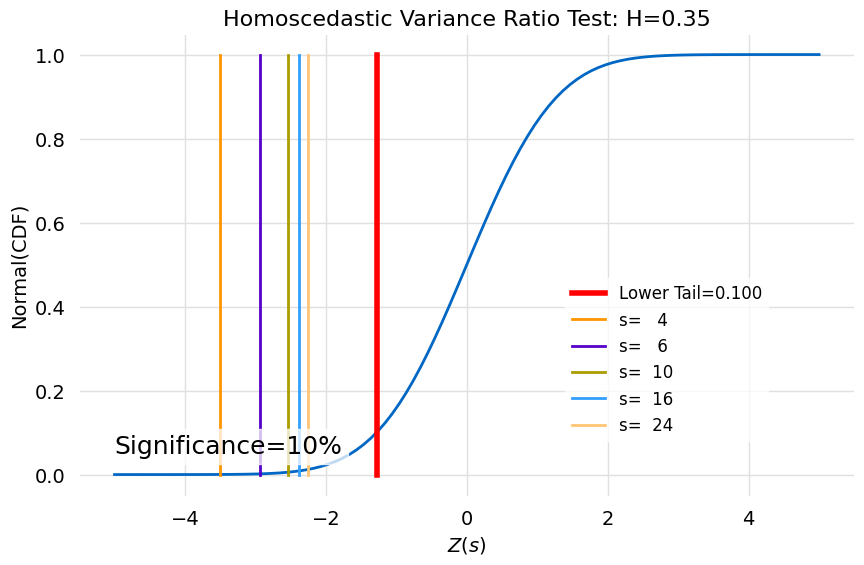

In [123]:
homo_test_stat_plot(result, H)

In [124]:
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.FBM_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.UPPER_TAIL        │
├──────────────────────┼──────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_AUTO_CORR │
├──────────────────────┼──────────────────────────────────┤
│ Significance         │ 10%                              │
├──────────────────────┼──────────────────────────────────┤
│ Upper Critical Value │ 1.282                            │
╘══════════════════════╧══════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -3.502 │    1     │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -2.938 │    0.998 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -2.542 │    0.994 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -2.389 │    0.992 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  24 │ -2.251 │    0.988 │ Pas

In [125]:
print(result_model.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "UPPER_TAIL",
    "hyp_test_type": "AUTO_CORR",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "label": "$Z(s)$",
                "value": -3.502475603609552,
                "hyp_test_id": "648b0b48-23be-4b72-8b71-29bd0b3b3ef3"
            },
            "pval": {
                "label": "$p-value$",
                "value": 0.9997695220025901,
                "hyp_test_id": "648b0b48-23be-4b72-8b71-29bd0b3b3ef3"
            },
            "params": [
                {
                    "label": "$s$",
                    "value": 4,
                    "hyp_test_id": "648b0b48-23be-4b72-8b71-29bd0b3b3ef3"
                }
            ],
            "sig": {
                "label": "10%",
                "value": 0.1,
                "hyp_test_id": "648b0b48-23be-4b72-8b71-29bd0b3b3ef3"
            },
            "lower": null,
            "upper": {
                "label": "$Z_U(s)$",


In [126]:
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -3.502 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -2.938 │    0.003 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -2.542 │    0.011 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -2.389 │    0.017 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  24 │ -2

In [127]:
print(result_model.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "TWO_TAIL",
    "hyp_test_type": "BM",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "label": "$Z(s)$",
                "value": -3.502475603609552,
                "hyp_test_id": "45c8c579-f553-48e1-975a-c66968695804"
            },
            "pval": {
                "label": "$p-value$",
                "value": 0.00046095599481987826,
                "hyp_test_id": "45c8c579-f553-48e1-975a-c66968695804"
            },
            "params": [
                {
                    "label": "$s$",
                    "value": 4,
                    "hyp_test_id": "45c8c579-f553-48e1-975a-c66968695804"
                }
            ],
            "sig": {
                "label": "10%",
                "value": 0.1,
                "hyp_test_id": "45c8c579-f553-48e1-975a-c66968695804"
            },
            "lower": {
                "label": "$Z_L(s)$",
                "value": -1.6448

### $H = 0.6$

Here an upper tailed test for fractional brownian motion with $H > \frac{1}{2}$. The test is successful if the result is **Failed**.

In [128]:
H=0.6
t, samples = fbm.create_fft_source(H=H, npts=npts)
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.FBM_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.UPPER_TAIL        │
├──────────────────────┼──────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_AUTO_CORR │
├──────────────────────┼──────────────────────────────────┤
│ Significance         │ 10%                              │
├──────────────────────┼──────────────────────────────────┤
│ Upper Critical Value │ 1.282                            │
╘══════════════════════╧══════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  3.528 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  2.912 │    0.002 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  2.824 │    0.002 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  2.922 │    0.002 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  24 │  2.808 │    0.002 │ Fai

In [129]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "UPPER_TAIL",
    "hyp_test_type": "AUTO_CORR",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "label": "$Z(s)$",
                "value": 3.5278846275566504,
                "hyp_test_id": "aec04720-43b0-4540-83fa-5a6b8308302c"
            },
            "pval": {
                "label": "$p-value$",
                "value": 0.00020944734573447032,
                "hyp_test_id": "aec04720-43b0-4540-83fa-5a6b8308302c"
            },
            "params": [
                {
                    "label": "$s$",
                    "value": 4,
                    "hyp_test_id": "aec04720-43b0-4540-83fa-5a6b8308302c"
                }
            ],
            "sig": {
                "label": "10%",
                "value": 0.1,
                "hyp_test_id": "aec04720-43b0-4540-83fa-5a6b8308302c"
            },
            "lower": null,
            "upper": {
                "label": "$Z_U(s)

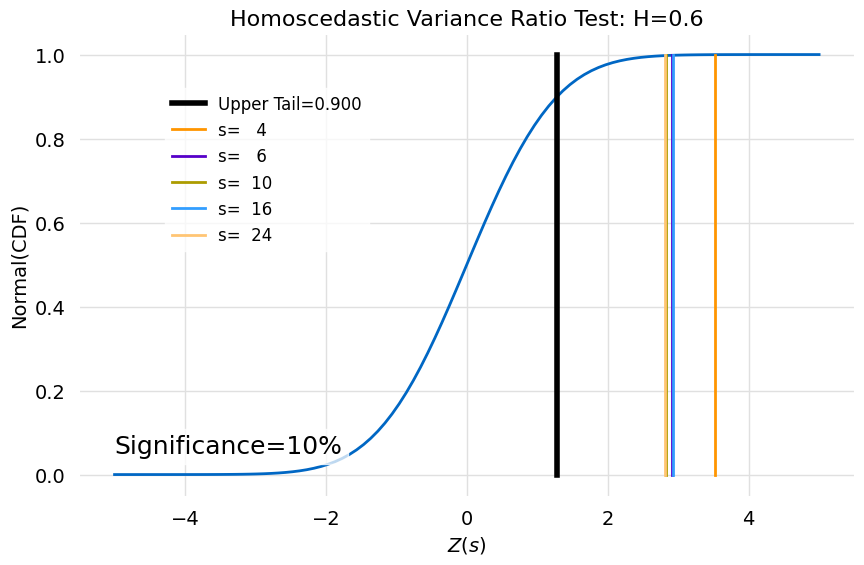

In [130]:
homo_test_stat_plot(result, H)

In [131]:
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.FBM_NEG_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.LOWER_TAIL            │
├──────────────────────┼──────────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_NEG_AUTO_CORR │
├──────────────────────┼──────────────────────────────────────┤
│ Significance         │ 10%                                  │
├──────────────────────┼──────────────────────────────────────┤
│ Lower Critical Value │ -1.282                               │
╘══════════════════════╧══════════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  3.528 │    1     │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  2.912 │    0.998 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  2.824 │    0.998 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  2.922 │    0.998 │ Passed   │
├─────┼────────┼──────────┼───────

In [132]:
print(result_model.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "NEG_AUTO_CORR",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "label": "$Z(s)$",
                "value": 3.5278846275566504,
                "hyp_test_id": "4d8e87ca-cd21-4b6e-a3b5-f1c28ad9b29c"
            },
            "pval": {
                "label": "$p-value$",
                "value": 0.9997905526542655,
                "hyp_test_id": "4d8e87ca-cd21-4b6e-a3b5-f1c28ad9b29c"
            },
            "params": [
                {
                    "label": "$s$",
                    "value": 4,
                    "hyp_test_id": "4d8e87ca-cd21-4b6e-a3b5-f1c28ad9b29c"
                }
            ],
            "sig": {
                "label": "10%",
                "value": 0.1,
                "hyp_test_id": "4d8e87ca-cd21-4b6e-a3b5-f1c28ad9b29c"
            },
            "lower": {
                "label": "$Z_L(s)$",
                "value"

In [133]:
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  3.528 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  2.912 │    0.004 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  2.824 │    0.005 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  2.922 │    0.003 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  24 │  2

In [134]:
print(result_model.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "TWO_TAIL",
    "hyp_test_type": "BM",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "label": "$Z(s)$",
                "value": 3.5278846275566504,
                "hyp_test_id": "24e6308d-0224-4e02-a3e9-64a5ccba24a9"
            },
            "pval": {
                "label": "$p-value$",
                "value": 0.00041889469146894065,
                "hyp_test_id": "24e6308d-0224-4e02-a3e9-64a5ccba24a9"
            },
            "params": [
                {
                    "label": "$s$",
                    "value": 4,
                    "hyp_test_id": "24e6308d-0224-4e02-a3e9-64a5ccba24a9"
                }
            ],
            "sig": {
                "label": "10%",
                "value": 0.1,
                "hyp_test_id": "24e6308d-0224-4e02-a3e9-64a5ccba24a9"
            },
            "lower": {
                "label": "$Z_L(s)$",
                "value": -1.6448